> **Resultados actuales guardados — cierre del kernel fallido.**
> Las 21 celdas se ejecutaron en Jupyter real con ArcGIS Pro el 17/09/2026: cero errores de celda y 16 PNG nativos incrustados. El kernel abortó después de guardar las salidas y comprobar las entradas; no es una ejecución integral sin errores. Véase la procedencia final.
> Los resultados históricos permanecen separados. Video parcialmente revisado; clase no declarada completa.

**Docente:** Fabian Cetina

**Procedencia:** notebook fuente `Clase 15 - Cubos espacio-temporales y patrones emergentes.ipynb`, vault original `../diplomado_geoia/99 - Recursos/notebooks/`. La identidad Clase 15 corresponde a la fuente; Clase 03 corresponde al destino. Se conserva la atribución de la fuente y no se atribuye su autoría al docente destino.


# Clase 03 — Cubos espacio-temporales y patrones emergentes

Práctica reproducible para ArcGIS Pro con `arcpy`, `arcpy.stpm`, `arcpy.stats` y `arcpy.charts`.

## Guía rápida

Esta práctica reproduce el flujo central de la clase:

1. Revisar datos de siniestros viales y área de análisis.
2. Describir un cubo espacio-temporal existente en formato NetCDF.
3. Visualizar el cubo en 2D y 3D.
4. Ejecutar **Emerging Hot Spot Analysis**.
5. Contrastar con **Optimized Hot Spot Analysis** en 2D.
6. Exportar tablas y gráficos con **ArcPy Charts**.

> Ejecutar con el Python de ArcGIS Pro. En este equipo corresponde a `arcgispro-py3`.

## 0. Preparación del entorno

### Qué hace

La primera celda configura ROOT, DATA_DIR y OUTPUT_DIR; la siguiente celda de código importa ArcPy y prepara una carpeta única de ejecución con geodatabases de trabajo y scratch.

### Por qué

Evita rutas manuales y deja el flujo repetible desde el repositorio.

### Para qué

Para que cualquier ejecución posterior regenere tablas, reportes y gráficos sin depender de la interfaz de ArcGIS Pro.

### Después de ejecutar

Debe quedar disponible una geodatabase de trabajo y una carpeta de salidas con CSV, reportes y gráficos PNG.

In [1]:
# Busca el vault desde la carpeta actual o sus ancestros; no crea archivos aquí.
from pathlib import Path
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / '99 - Recursos/datos/clase_03/entradas.gdb').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Abra el notebook dentro del vault o configure ROOT explícitamente.')
# Para rutas externas, sustituya ROOT o estas dos rutas por Path absolutos separados.
DATA_DIR = ROOT / '99 - Recursos/datos/clase_03'
OUTPUT_DIR = ROOT / '99 - Recursos/salidas_clase_03/practica_01'

## 1. Exploración inicial de campos

### Qué hace

Lista campos principales y detecta campos de fecha en `SiniestrosViales`.

### Por qué

El cubo necesita una geometría y un campo temporal confiable; si la fecha está mal, el patrón temporal también estará mal.

### Para qué

Para justificar qué campo alimenta el eje temporal y qué variables sirven para segmentar o interpretar resultados.

### Después de ejecutar

Se identifican campos como fecha de ocurrencia, gravedad, clase de accidente y localidad.

In [2]:
# Aísla cada ejecución y copia el cubo: Emerging modifica su entrada NetCDF.
import csv
import shutil
from uuid import uuid4
import arcpy
from IPython.display import Image, display

if DATA_DIR.resolve() == OUTPUT_DIR.resolve() or DATA_DIR.resolve() in OUTPUT_DIR.resolve().parents:
    raise ValueError('OUTPUT_DIR debe quedar fuera de DATA_DIR.')
OUT_DIR = OUTPUT_DIR / ('run_' + uuid4().hex)
OUT_DIR.mkdir(parents=True, exist_ok=False)
GDB = DATA_DIR / 'entradas.gdb'
SINESTROS = str(GDB / 'SiniestrosViales')
UPZ = str(GDB / 'UPZ')
CUBE_SOURCE = DATA_DIR / 'cubo_espacio_temporal_accidentes.nc'
CUBE = str(OUT_DIR / CUBE_SOURCE.name)
shutil.copy2(CUBE_SOURCE, CUBE)
WORK_GDB = OUT_DIR / 'trabajo.gdb'
SCRATCH_GDB = OUT_DIR / 'scratch.gdb'
arcpy.env.overwriteOutput = True
for gdb in (WORK_GDB, SCRATCH_GDB):
    arcpy.management.CreateFileGDB(str(gdb.parent), gdb.name)
arcpy.env.workspace = str(WORK_GDB)
arcpy.env.scratchWorkspace = str(SCRATCH_GDB)
print('Salidas de esta ejecución:', OUT_DIR)
print('Siniestros:', arcpy.management.GetCount(SINESTROS)[0])
print('UPZ:', arcpy.management.GetCount(UPZ)[0])
# Inspecciona campos sin modificar las entidades preparadas.
fields = arcpy.ListFields(SINESTROS)
for field in fields[:20]:
    print(f'{field.name:25s} {field.type}')

fecha_fields = [f.name for f in fields if f.type == 'Date']
print('\nCampos de fecha:', fecha_fields)


Salidas de esta ejecución: C:\Users\[USER]\OneDrive - Esri NOSA\diplomado_geoia_v3\99 - Recursos\salidas_clase_03\practica_01\run_b01a1f3965b84ae2a861e185ead354dc
Siniestros: 199146


UPZ: 112
OBJECTID_1                OID
Shape                     Geometry
OBJECTID                  Integer
FORMULARIO                String
CODIGO_ACC                Integer
FECHA_OCUR                Date
ANO_OCURRE                SmallInteger
DIRECCION                 String
GRAVEDAD                  String
CLASE_ACC                 String
LOCALIDAD                 String
FECHA_HORA                Date
LATITUD                   Double
LONGITUD                  Double
CIV                       Integer
PK_CALZADA                Integer

Campos de fecha: ['FECHA_OCUR', 'FECHA_HORA']


### Leer los datos antes del cubo
El mapa sitúa los siniestros sobre UPZ de referencia; la superposición de puntos no mide tasas ni exposición. Las barras por mes de `FECHA_OCUR` describen cobertura temporal, y las de `LOCALIDAD` comparan registros, no riesgo. Los meses ausentes no se rellenan: ausencia de filas no demuestra cero eventos. Nulo es desconocido; cero es un valor observado. No se imputan fechas, localidades ni conteos.

Un único proyecto local organiza mapas, escena y layouts. Solo sus copias cartográficas y resultados se enlazan al APRX: ninguna capa del proyecto apunta a las entradas originales. Se conserva el CRS de cada salida; el pie muestra nombre y unidades. Proyectado en metros no significa libre de distorsión, especialmente a escala nacional: no interprete distancias medidas sobre el PNG como distancias geodésicas ni cambie proyección para mejorar una imagen. Los mapas 2D llevan norte arriba y escala nominal. No se consulta mapa base ni elevación remota.

Los auxiliares pequeños siguientes solo presentan y resumen datos; no reemplazan los modelos. Se adaptó el diseño local de Clase 02 P01. API consultada: docstrings y definiciones CIM instaladas de Esri ArcGIS Pro 3.6.2 (`createMap`, `createLayout`, `createMapSurroundElement`, `Camera`, `Bar`, `Histogram`); renderizado comprobado en la ejecución guardada; límites visuales y fallo de cierre al final.


In [3]:
# Un APRX de salida y copias de trabajo evitan enlazar entradas al proyecto.
from collections import Counter
import math
info = arcpy.GetInstallInfo()
template = Path(info['InstallDir']) / 'Resources/ArcToolBox/Services/routingservices/data/Blank.aprx'
if not template.is_file():
    raise FileNotFoundError('Falta la plantilla local Blank.aprx de ArcGIS Pro.')
aprx_path = OUT_DIR / 'clase03_resultados.aprx'
seed = arcpy.mp.ArcGISProject(str(template))
seed.saveACopy(str(aprx_path))
del seed
project = arcpy.mp.ArcGISProject(str(aprx_path))
for existing_map in project.listMaps():
    project.deleteItem(existing_map)
project.defaultGeodatabase = str(WORK_GDB)
visual_outputs, visual_blocks = [], []
siniestros_mapa = str(WORK_GDB / 'Siniestros_cartografia')
upz_mapa = str(WORK_GDB / 'UPZ_cartografia')
arcpy.management.CopyFeatures(SINESTROS, siniestros_mapa)
arcpy.management.CopyFeatures(UPZ, upz_mapa)
print('ArcGIS Pro', info['Version'], '| licencia', arcpy.ProductInfo())

def rect(x0, y0, x1, y1):
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0), arcpy.Point(x1,y0),
                                      arcpy.Point(x1,y1), arcpy.Point(x0,y1)]))

def native_chart(chart, name):
    chart.theme = 'Light'
    chart.description = 'Elaboración docente · entradas locales Clase 03 · ejecución actual'
    png = OUT_DIR / (name + '.png')
    chart.exportToPNG(str(png), 1500, 950)
    visual_outputs.append(png.name)
    display(Image(filename=str(png), width=1100))

def count_chart(counter, name, title, unit='Filas'):
    # La tabla scratch conserva nulos como categoría explícita, no como cero.
    table = str(SCRATCH_GDB / name)
    arcpy.management.CreateTable(str(SCRATCH_GDB), name)
    arcpy.management.AddField(table, 'Categoria', 'TEXT', field_length=255)
    arcpy.management.AddField(table, 'Cantidad', 'LONG')
    with arcpy.da.InsertCursor(table, ['Categoria', 'Cantidad']) as cursor:
        for key, value in sorted(counter.items(), key=lambda item: str(item[0])):
            cursor.insertRow(('(Nulo)' if key is None else str(key), value))
    chart = arcpy.charts.Bar(x='Categoria', y='Cantidad', aggregation='SUM',
                             title=title, xTitle='Categoría', yTitle=unit, dataSource=table)
    native_chart(chart, name)
    print(title, dict(counter))


ArcGIS Pro 3.6.2 | licencia ArcInfo


In [4]:
# Un layout por tema: leyenda real, CRS observado y ninguna fuente remota.
gi_names = {-3:'Frío 99%', -2:'Frío 95%', -1:'Frío 90%', 0:'No significativo',
            1:'Caliente 90%', 2:'Caliente 95%', 3:'Caliente 99%'}
gi_colors = [[33,102,172,100], [67,147,195,100], [146,197,222,100], [205,205,205,100],
             [244,165,130,100], [214,96,77,100], [178,24,43,100]]
def native_map(fc, name, title, field=None, context=None, scene=False):
    fc = str(fc)
    if not Path(fc).resolve().is_relative_to(OUT_DIR.resolve()):
        raise ValueError('El APRX solo admite copias y resultados de OUT_DIR.')
    desc = arcpy.Describe(fc)
    sr = desc.spatialReference
    if sr.name == 'Unknown':
        raise ValueError('CRS desconocido: no se asigna una proyección arbitraria.')
    m = project.createMap(name, 'SCENE' if scene else 'MAP')
    for layer in m.listLayers():
        m.removeLayer(layer)
    # Quita también referencias CIM a superficies de elevación predeterminadas.
    definition = m.getDefinition('V3')
    definition.groundElevationSurfaceLayer = ''
    definition.customElevationSurfaceLayers = []
    m.setDefinition(definition)
    m.spatialReference = sr
    if context:
        if not Path(context).resolve().is_relative_to(OUT_DIR.resolve()):
            raise ValueError('El contexto debe ser una copia de salida.')
        backdrop = m.addDataFromPath(context)
        backdrop.name = 'UPZ de referencia'
        sym = backdrop.symbology
        sym.renderer.symbol.color = {'RGB':[245,245,240,100]}
        sym.renderer.symbol.outlineColor = {'RGB':[130,140,145,100]}
        sym.renderer.symbol.outlineWidth = 0.5
        backdrop.symbology = sym
    layer = m.addDataFromPath(fc)
    layer.name = field or title
    sym = layer.symbology
    if field:
        if field not in [f.name for f in arcpy.ListFields(fc)]:
            raise ValueError(f'Falta {field}; revisar esquema observado de {name}.')
        sym.updateRenderer('GraduatedColorsRenderer' if scene else 'UniqueValueRenderer')
        if scene:
            sym.renderer.classificationField = field
            sym.renderer.breakCount = 5
        else:
            sym.renderer.fields = [field]
            for group in sym.renderer.groups:
                for item in group.items:
                    value = str(item.values[0][0])
                    if field in ('Gi_Bin', 'TREND_BIN') and value.lstrip('-').isdigit():
                        code = int(value)
                        if code in gi_names:
                            item.symbol.color = {'RGB':gi_colors[code+3]}
                            item.label = (gi_names[code] if field == 'Gi_Bin' else
                                          'Tendencia no significativa' if code == 0 else
                                          ('Decreciente' if code < 0 else 'Creciente') +
                                          ' ' + {1:'90%',2:'95%',3:'99%'}[abs(code)])
                    elif field == 'PATTERN':
                        # Ocho historias: colores distintos dentro de cada familia cálida/fría.
                        histories = ['new','consecutive','intensifying','persistent',
                                     'diminishing','sporadic','oscillating','historical']
                        hot = [[255,190,90],[235,125,35],[190,30,40],[120,10,30],
                               [180,95,55],[240,145,135],[175,65,110],[110,65,70]]
                        cold = [[170,220,245],[80,175,215],[25,90,190],[20,40,110],
                                [95,125,165],[125,185,175],[100,95,185],[80,75,110]]
                        text = value.lower()
                        index = next((i for i, word in enumerate(histories) if text.startswith(word)), None)
                        if index is not None and ('hot' in text or 'cold' in text):
                            item.symbol.color = {'RGB': (hot if 'hot' in text else cold)[index] + [100]}
                        elif 'no pattern' in text:
                            item.symbol.color = {'RGB':[190,190,190,100]}
                        # Códigos inesperados conservan su símbolo y etiqueta nativos.
    else:
        sym.renderer.symbol.color = {'RGB':[20,110,155,70]}
        if desc.shapeType in ('Point', 'Multipoint'):
            sym.renderer.symbol.size = 2
    layer.symbology = sym
    if field == 'PATTERN':
        # El renderer nuevo no conserva nombres de niveles del símbolo de Emerging.
        definition = layer.getDefinition('V3')
        definition.symbolLayerDrawing = None
        layer.setDefinition(definition)
    if scene:
        # Dibuja Z geométrica del cubo, no extrusión artificial de COUNT ni drapeado.
        definition = layer.getDefinition('V3')
        definition.isFlattened = False
        definition.layerElevation = None
        layer.setDefinition(definition)
    layout = project.createLayout(14, 10, 'INCH', name)
    frame = layout.createMapFrame(rect(.4,1.2,9.7,8.7), m, 'Mapa')
    if scene:
        # Pro 3.6.2 crea el marco con modo MAP aun cuando el mapa es SCENE.
        # CIMMapView.viewingMode instalado permite activar la vista SceneLocal.
        frame_definition = frame.getDefinition('V3')
        frame_definition.view.viewingMode = 'SceneLocal'
        frame.setDefinition(frame_definition)
    frame.camera.setExtent(frame.getLayerExtent(layer, False, True))
    frame.camera.scale *= 1.15
    if scene:
        if m.mapType != 'SCENE' or frame.camera.mode != 'LOCAL':
            raise RuntimeError('No se obtuvo una cámara de escena local 3D.')
        # El marco recién convertido conservaba Camera.Z = NaN: fijar una cámara finita.
        extent = frame.getLayerExtent(layer, False, False)
        height = max(extent.width, extent.height)
        frame.camera.X = (extent.XMin + extent.XMax) / 2
        frame.camera.Y = (extent.YMin + extent.YMax) / 2 - height / math.tan(math.radians(60))
        frame.camera.Z = height + z_max
        frame.camera.pitch = -60
        frame.camera.heading = 0
    legend = layout.createMapSurroundElement(rect(10,1.3,13.7,8.6), 'LEGEND', frame, None, 'Leyenda')
    legend.fittingStrategy = 'AdjustFontSize'
    project.createTextElement(layout, arcpy.Point(.4,9.2), 'POINT', title, 16, 'Segoe UI', 'Regular')
    units = sr.linearUnitName if sr.type == 'Projected' else sr.angularUnitName
    view = 'Z = tiempo del cubo; color = COUNT, no altitud' if scene else f'N arriba | escala 1:{frame.camera.scale:,.0f}'
    footer = f'{view}\n{sr.name} | {units} | Elaboración docente · datos locales Clase 03'
    project.createTextElement(layout, arcpy.Point(.4,.75), 'POINT', footer, 9, 'Segoe UI', 'Regular')
    png = OUT_DIR / (name + '.png')
    project.save()
    layout.exportToPNG(str(png), resolution=160)
    visual_outputs.append(png.name)
    display(Image(filename=str(png), width=1100))
    print('CRS:', sr.name, '| unidades:', units, '| entidades:', arcpy.management.GetCount(fc)[0])


Filas: 199146 | fechas nulas: 0 | localidades nulas: 0
Lectura: una barra alta es más registros; no ajusta por población ni tráfico.


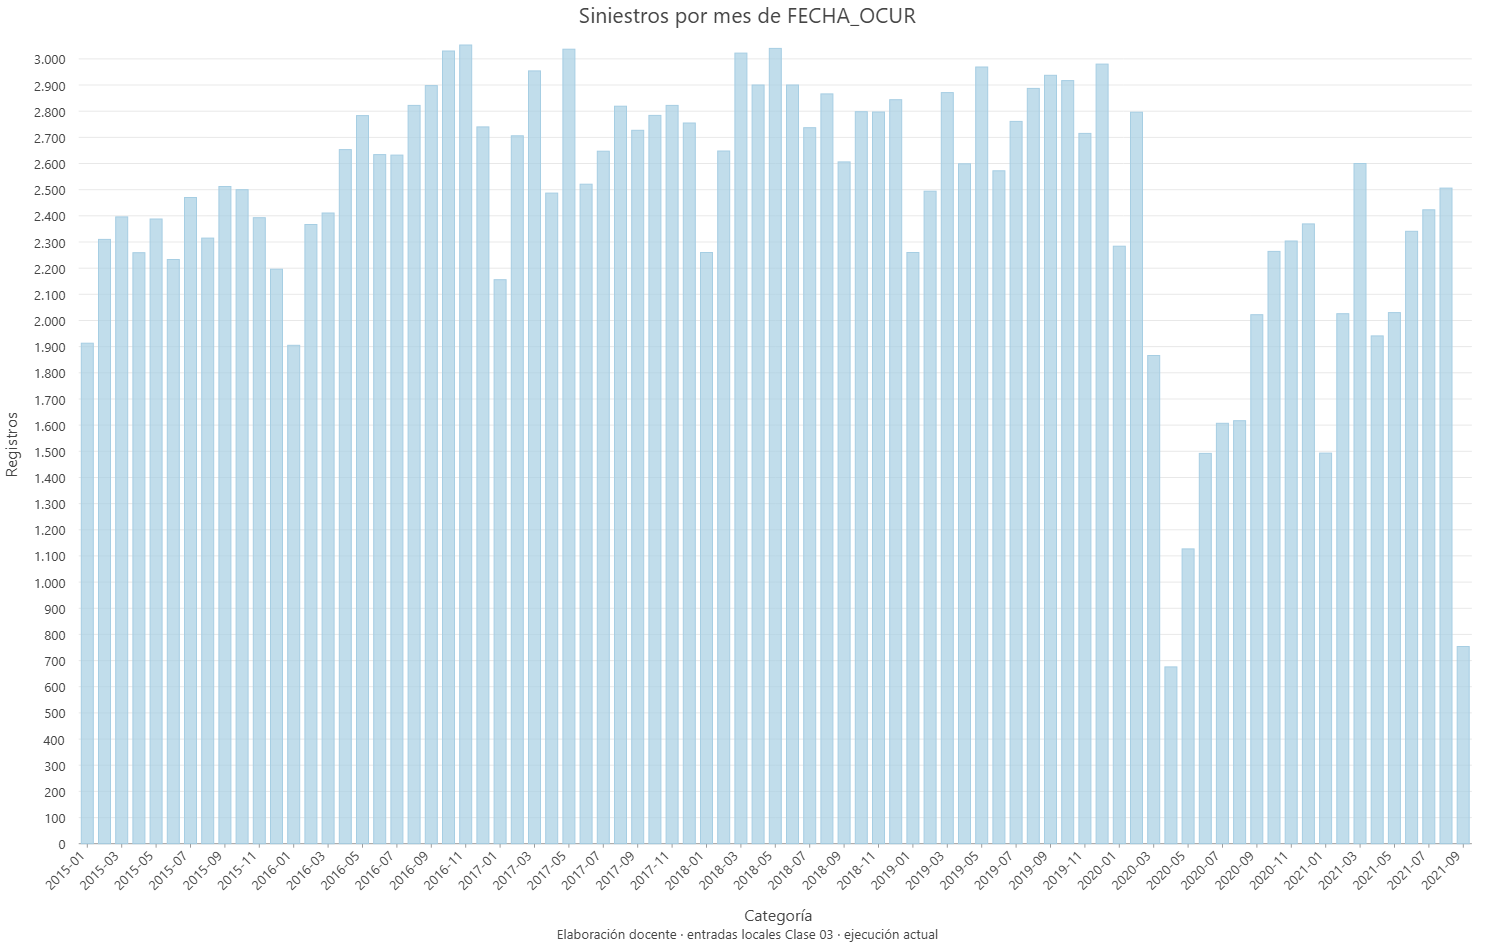

Siniestros por mes de FECHA_OCUR {'2017-06': 2521, '2020-11': 2304, '2015-05': 2388, '2016-06': 2634, '2020-08': 1617, '2015-09': 2512, '2016-12': 2740, '2017-10': 2784, '2020-09': 2022, '2017-09': 2727, '2018-05': 3040, '2016-10': 3030, '2020-12': 2369, '2020-01': 2284, '2020-05': 1127, '2020-10': 2264, '2016-03': 2411, '2015-12': 2196, '2017-01': 2156, '2015-06': 2233, '2017-11': 2822, '2015-04': 2259, '2015-08': 2315, '2015-11': 2393, '2017-05': 3037, '2016-11': 3053, '2015-03': 2396, '2015-10': 2500, '2017-04': 2487, '2017-08': 2819, '2017-12': 2755, '2017-02': 2706, '2016-05': 2783, '2018-04': 2900, '2017-07': 2647, '2016-08': 2822, '2015-02': 2310, '2016-01': 1905, '2016-07': 2632, '2018-01': 2260, '2016-04': 2653, '2016-09': 2898, '2018-02': 2648, '2018-03': 3022, '2015-07': 2470, '2015-01': 1913, '2020-07': 1607, '2020-06': 1492, '2017-03': 2954, '2021-03': 2600, '2021-01': 1493, '2021-02': 2026, '2021-04': 1941, '2021-07': 2423, '2021-09': 754, '2021-08': 2506, '2021-06': 2341

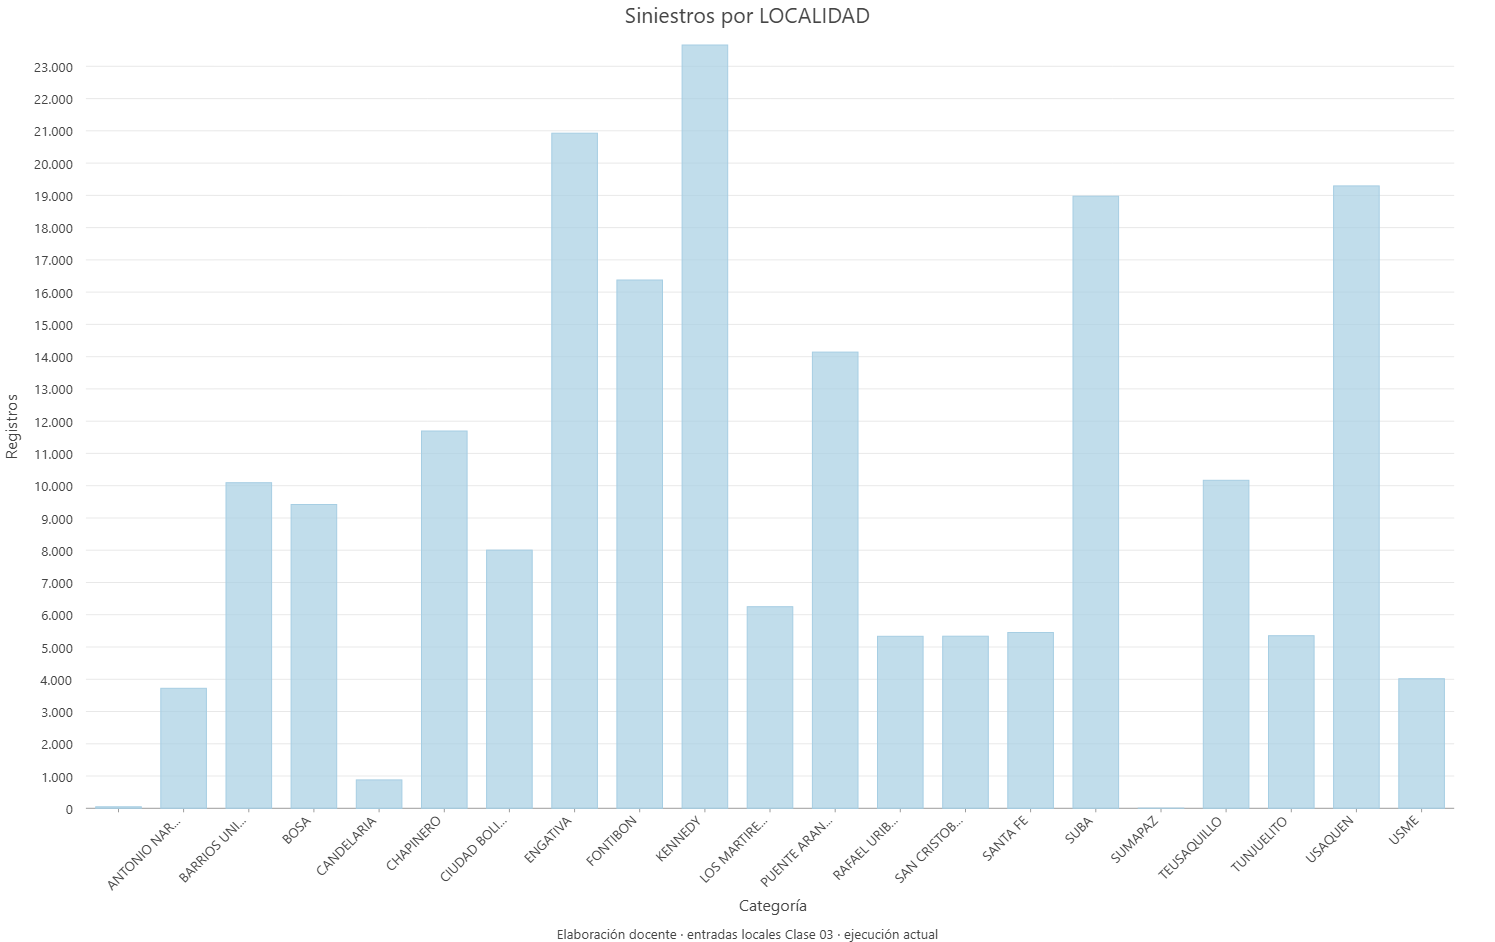

Siniestros por LOCALIDAD {'ENGATIVA': 20928, 'PUENTE ARANDA': 14143, 'USAQUEN': 19292, 'CIUDAD BOLIVAR': 8005, 'LOS MARTIRES': 6250, 'SUBA': 18973, 'FONTIBON': 16377, 'USME': 4017, 'TEUSAQUILLO': 10167, 'BARRIOS UNIDOS': 10094, 'RAFAEL URIBE URIBE': 5333, 'CHAPINERO': 11696, 'KENNEDY': 23661, 'ANTONIO NARINO': 3721, 'BOSA': 9417, 'SAN CRISTOBAL': 5335, 'CANDELARIA': 882, 'TUNJUELITO': 5351, 'SANTA FE': 5451, ' ': 46, 'SUMAPAZ': 7}


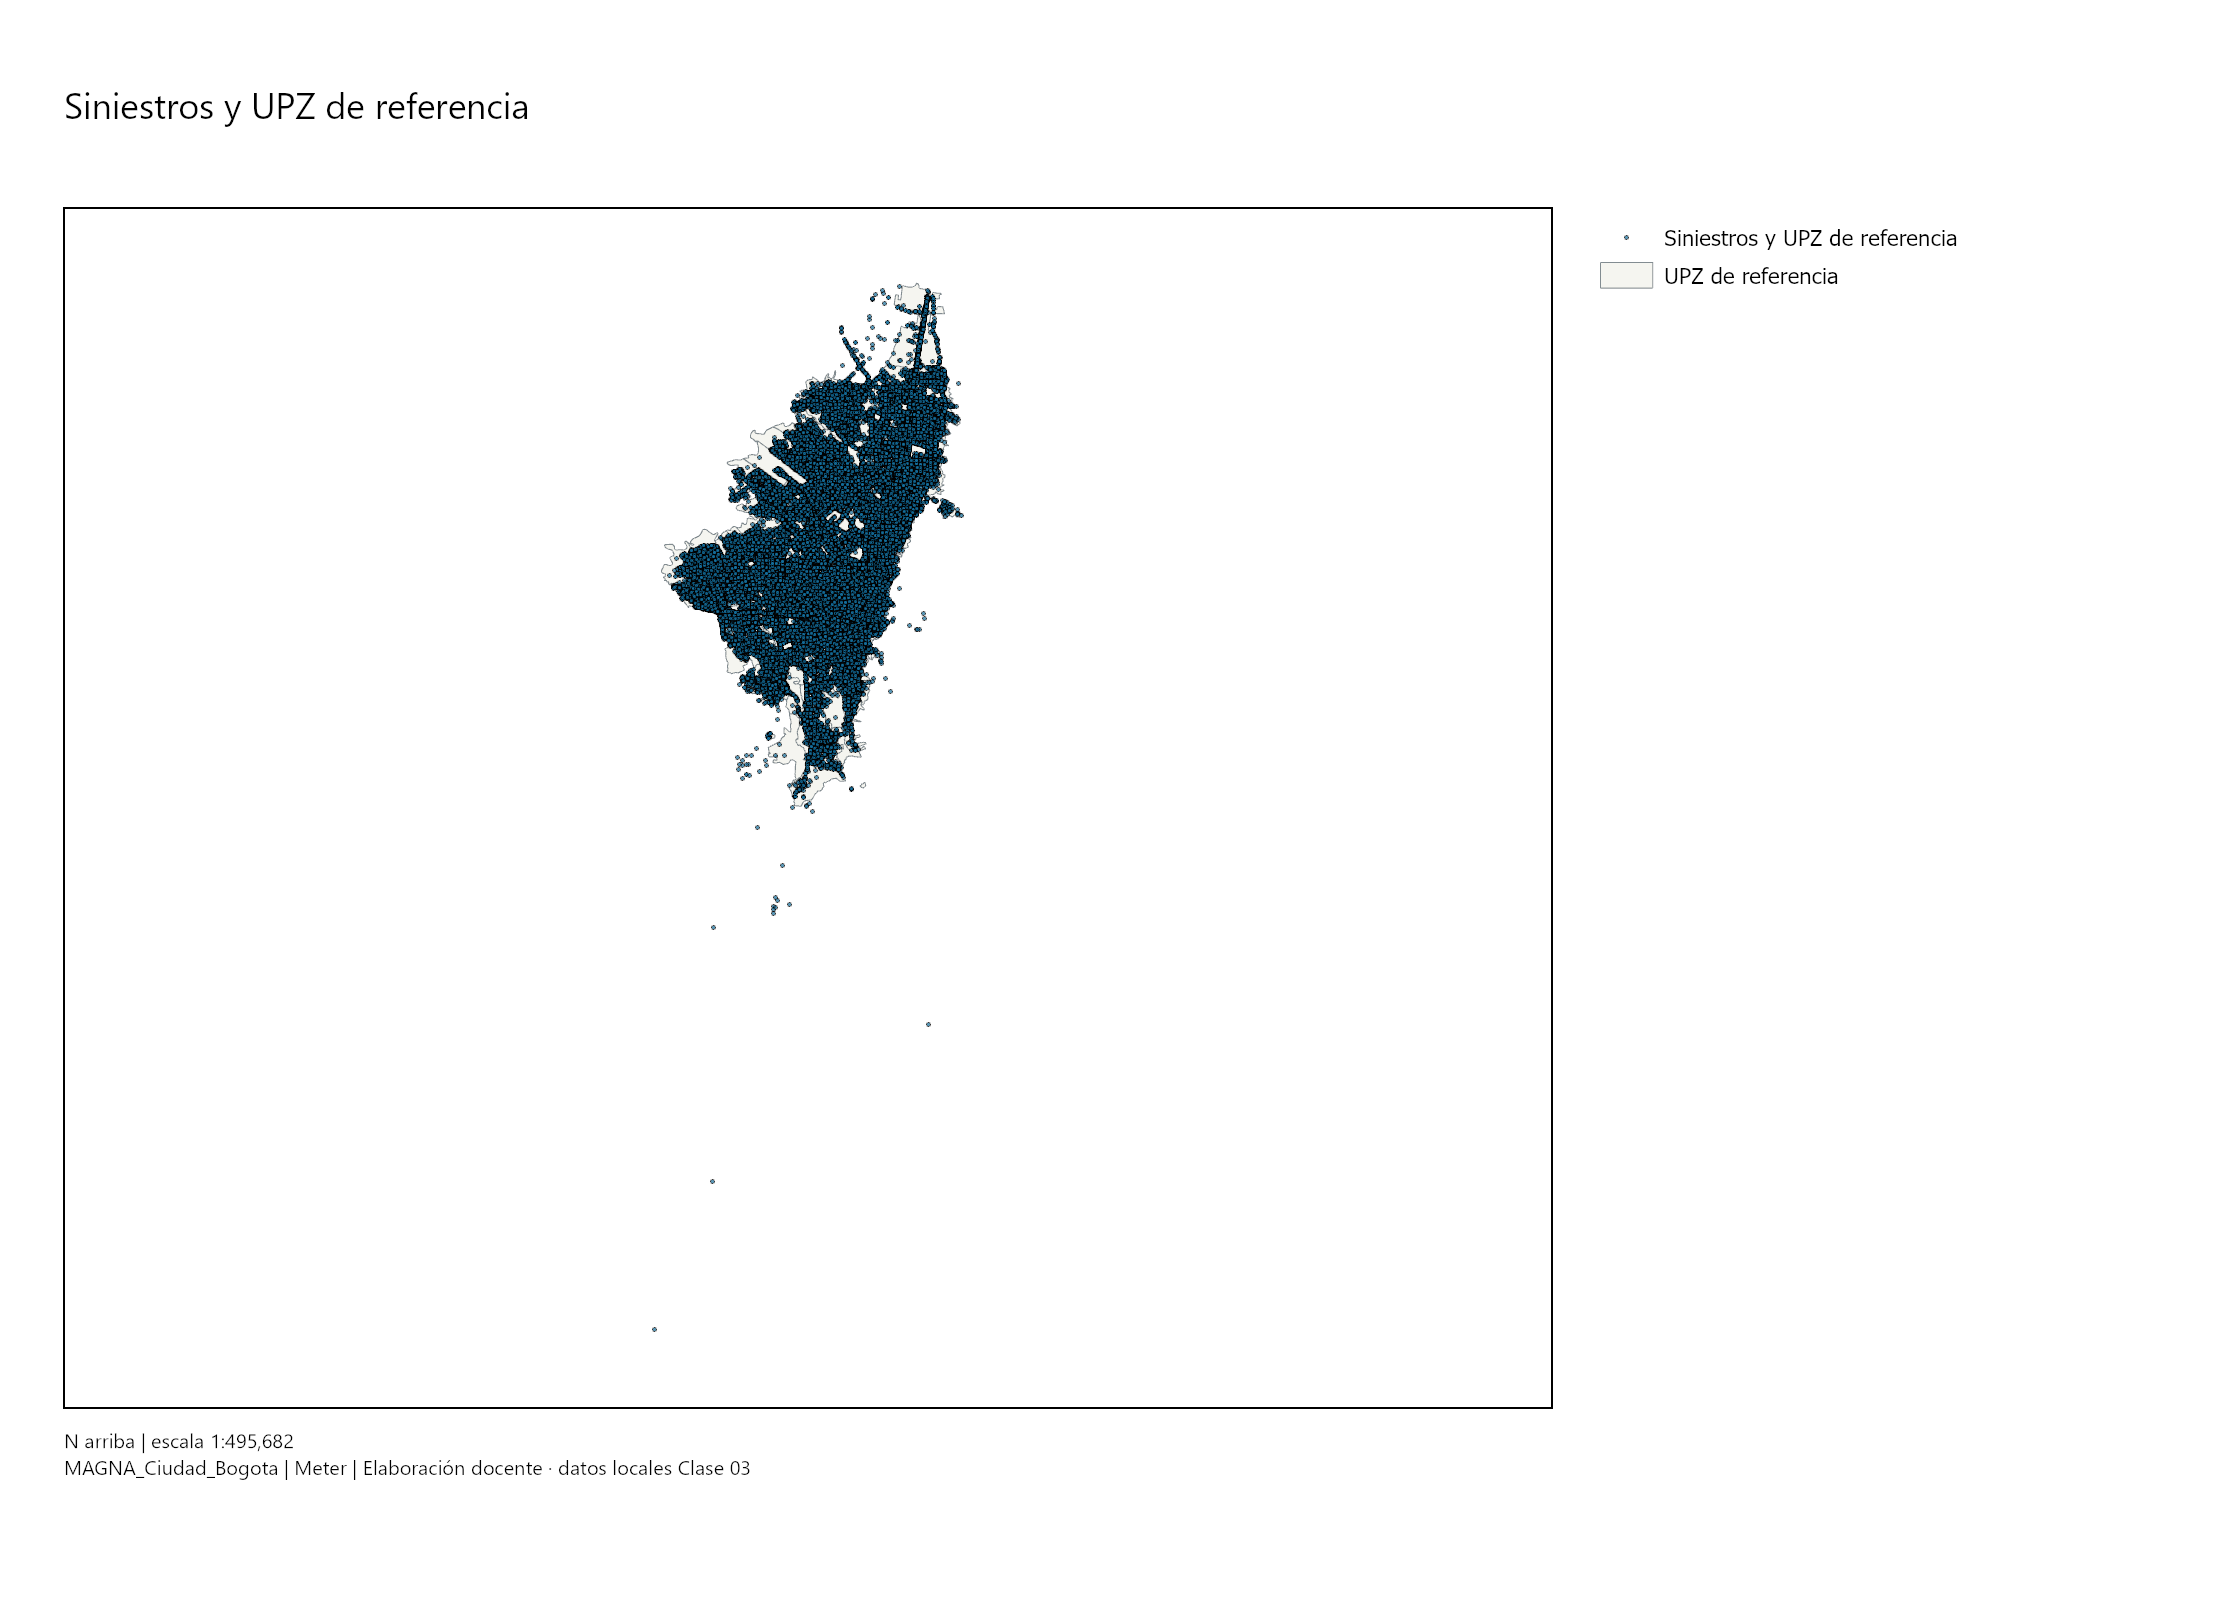

CRS: MAGNA_Ciudad_Bogota | unidades: Meter | entidades: 199146


In [5]:
# Resume fechas y localidades en scratch sin transformar los eventos.
months, localities = Counter(), Counter()
with arcpy.da.SearchCursor(SINESTROS, ['FECHA_OCUR', 'LOCALIDAD']) as cursor:
    for date, locality in cursor:
        months[date.strftime('%Y-%m') if date is not None else None] += 1
        localities[locality] += 1
print('Filas:', sum(months.values()), '| fechas nulas:', months[None], '| localidades nulas:', localities[None])
print('Lectura: una barra alta es más registros; no ajusta por población ni tráfico.')
count_chart(months, 'eda_siniestros_mes', 'Siniestros por mes de FECHA_OCUR', 'Registros')
count_chart(localities, 'eda_siniestros_localidad', 'Siniestros por LOCALIDAD', 'Registros')
native_map(siniestros_mapa, 'mapa_siniestros_upz', 'Siniestros y UPZ de referencia', context=upz_mapa)


**Lectura de la EDA actual:** 199.146 filas, sin fechas ni localidades nulas. Esto no garantiza categorías válidas: 46 localidades contienen un espacio en blanco y se conservan, sin imputar. Kennedy reúne 23.661 registros; abril de 2020 contiene 676. Son volúmenes, no tasas ni explicación causal.

## 2. Describir el cubo espacio-temporal

### Qué hace

Ejecuta `DescribeSpaceTimeCube` sobre el archivo NetCDF de accidentes.

### Por qué

Un cubo sin metadatos no es auditable: hay que saber cuántos pasos temporales tiene, qué intervalo usa y qué tan dispersos son sus bins.

### Para qué

Para citar en la nota el rango temporal, número de bins, tendencia global y parámetros de agregación.

### Después de ejecutar

El reporte se guarda como texto para citarlo en la nota de clase.

In [6]:
# Describe la copia de trabajo y guarda el reporte en esta ejecución.
arcpy.stpm.DescribeSpaceTimeCube(CUBE)
report = arcpy.GetMessages()
report_path = OUT_DIR / 'describe_cubo_espacio_temporal_accidentes.txt'
report_path.write_text(report, encoding='utf-8')
print(report)
print('Reporte guardado en:', report_path)

Start Time: jueves, 17 de septiembre de 2026 3:28:31 p. m.
Grid Cube created with ArcGIS Pro 3.6.2 on Thu Jun 25 18:42:17 2026
***********************************
* Space Time Cube Characteristics *
***********************************
******************************************************

Input feature time extent          2015-01-01 00:00:00
                                to 2021-09-10 00:00:00
Shape type                                     Hexagon
                                                      
Number of time steps                                14
Time step interval                            6 months
Time step alignment                                End
                                                      
First time step temporal bias                   62.43%
First time step interval                         after
                                   2014-09-10 00:00:00
                                       to on or before
                                   2015-03-10 00:

**Lectura del reporte actual:** describe el cubo histórico reutilizado, no uno recién construido: 14 semestres, 132.468 bins de malla y 1.885 ubicaciones con eventos. COUNT global z=0,3285 y p=0,7426 no muestra tendencia significativa; sesgo inicial de 62,43 % limita comparar el primer semestre.

## 3A. Cómo se crea el cubo, usando la salida ya creada

### Qué hace

Muestra la llamada de ArcPy que reproduce **Create Space Time Cube By Aggregating Points**.

### Por qué

En la clase se creó el cubo desde `SiniestrosViales`, pero para no recalcularlo cada vez en el notebook se usa el NetCDF ya generado: `99 - Recursos/datos/clase_03/cubo_espacio_temporal_accidentes.nc`, copiado primero a la carpeta de ejecución.

### Para qué

Dejar documentado el parámetro clave: puntos de entrada, campo de fecha, intervalo temporal de seis meses, hexágonos y distancia espacial de 500 m.

In [7]:
# Esta celda documenta cómo se creó el cubo; no lo reejecuta por defecto.
# Si se necesita regenerar el NetCDF, descomentar y ejecutar:
#
# arcpy.stpm.CreateSpaceTimeCube(
#     in_features=SINESTROS,
#     output_cube=CUBE,
#     time_field='FECHA_OCUR',
#     time_step_interval='6 Months',
#     time_step_alignment='END_TIME',
#     distance_interval='500 Meters',
#     aggregation_shape_type='HEXAGON_GRID'
# )

print('Se usa el cubo ya creado:', CUBE)
print('Existe:', Path(CUBE).exists())
print('Motivo: evitar recalcular una salida pesada y mantener el notebook reproducible desde la salida oficial de práctica.')

Se usa el cubo ya creado: C:\Users\[USER]\OneDrive - Esri NOSA\diplomado_geoia_v3\99 - Recursos\salidas_clase_03\practica_01\run_b01a1f3965b84ae2a861e185ead354dc\cubo_espacio_temporal_accidentes.nc
Existe: True
Motivo: evitar recalcular una salida pesada y mantener el notebook reproducible desde la salida oficial de práctica.


## 3. Visualizar el cubo en 2D y 3D

### Qué hace

Convierte el NetCDF en capas 2D y 3D: ubicaciones con datos, tendencias y bins con conteos.

### Por qué

El archivo NetCDF es multidimensional; para mapearlo en ArcGIS Pro se debe transformar en entidades visualizables.

### Para qué

Para inspeccionar dónde hay datos, cómo se comportan las ubicaciones y cómo se apilan los intervalos temporales.

### Después de ejecutar

Se crean tres capas en la geodatabase de trabajo: ubicaciones con datos, tendencias 2D y bins 3D con conteos.

In [8]:
# Genera entidades 2D y 3D dentro de la geodatabase de salida, no mapas renderizados.
cube_2d_locations = str(WORK_GDB / 'Cubo2D_LocationsWithData')
cube_2d_trends = str(WORK_GDB / 'Cubo2D_Trends')
cube_3d_counts = str(WORK_GDB / 'Cubo3D_Counts')

arcpy.stpm.VisualizeSpaceTimeCube2D(CUBE, 'COUNT', 'LOCATIONS_WITH_DATA', cube_2d_locations, 'CREATE_POPUP')
arcpy.stpm.VisualizeSpaceTimeCube2D(CUBE, 'COUNT', 'TRENDS', cube_2d_trends, 'CREATE_POPUP')
arcpy.stpm.VisualizeSpaceTimeCube3D(CUBE, 'COUNT', 'VALUE', cube_3d_counts)

for label, fc in [('2D ubicaciones', cube_2d_locations), ('2D tendencias', cube_2d_trends), ('3D conteos', cube_3d_counts)]:
    print(label, arcpy.management.GetCount(fc)[0])

2D ubicaciones 1885
2D tendencias 1885


3D conteos 26390


## 4. Exportar tablas de visualización del cubo

### Antes de ejecutar

Las capas generadas por las herramientas de visualización contienen atributos útiles para revisar fuera del mapa.

### Después de ejecutar

Se crean CSV de ubicaciones, tendencias y bins 3D. Estos CSV alimentan la nota y facilitan revisión posterior.

In [9]:
# Exporta atributos con cursor de lectura; limita a 5000 filas el CSV 3D.
def export_table(fc, out_csv, max_rows=None):
    fields = [f.name for f in arcpy.ListFields(fc) if f.type not in ('Geometry', 'OID', 'Blob', 'Raster', 'GUID')]
    count = 0
    with open(out_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(fields)
        with arcpy.da.SearchCursor(fc, fields) as cursor:
            for row in cursor:
                writer.writerow(row)
                count += 1
                if max_rows and count >= max_rows:
                    break
    return count, fields

exports = {
    'tabla_cube_2d_locations.csv': cube_2d_locations,
    'tabla_cube_2d_trends.csv': cube_2d_trends,
    'tabla_cube_3d_counts.csv': cube_3d_counts,
}
for name, fc in exports.items():
    rows, fields = export_table(fc, OUT_DIR / name, max_rows=5000 if '3d' in name else None)
    print(name, rows, fields[:8])

tabla_cube_2d_locations.csv 1885 ['LOCATION', 'LOC_W_DATA', 'HTML_CHART', 'Shape_Length', 'Shape_Area']
tabla_cube_2d_trends.csv 1885 ['LOCATION', 'TREND_Z', 'TREND_P', 'TREND_BIN', 'HTML_CHART', 'Shape_Length', 'Shape_Area']


tabla_cube_3d_counts.csv 5000 ['TIME_STEP', 'START_DATE', 'END_DATE', 'TIME_EXAG', 'ELEMENT', 'LOCATION', 'VALUE']


## 5. Emerging Hot Spot Analysis

### Qué hace

Ejecuta `EmergingHotSpotAnalysis` sobre la variable `COUNT` del cubo.

### Por qué

Un mapa acumulado no dice si una zona se mantiene, aparece, se intensifica o se enfría.

### Para qué

Para priorizar ubicaciones con comportamiento temporal accionable: persistente, intensificado, nuevo u oscilante.

### Después de ejecutar

Se obtiene una capa con categorías como `Persistent Hot Spot`, `Intensifying Hot Spot`, `Oscillating Hot Spot`, `Persistent Cold Spot` y `No Pattern Detected`.

In [10]:
# Analiza únicamente CUBE, la copia aislada; conserva el NetCDF de DATA_DIR.
emerging_fc = str(WORK_GDB / 'EmergingHotSpot_Siniestros')

arcpy.stpm.EmergingHotSpotAnalysis(
    CUBE,
    'COUNT',
    emerging_fc,
    '',       # dejar distancia automática
    '2',      # vecinos temporales: 2 intervalos
    UPZ       # máscara de análisis
)

print('Ubicaciones analizadas:', arcpy.management.GetCount(emerging_fc)[0])
print(arcpy.GetMessages())

Ubicaciones analizadas: 2137
Start Time: jueves, 17 de septiembre de 2026 3:28:44 p. m.
Row Count = 2137
Succeeded at jueves, 17 de septiembre de 2026 3:28:44 p. m. (Elapsed Time: 0.04 seconds)


## 6. Resumir categorías emergentes

### Antes de ejecutar

La tabla de salida contiene un campo `PATTERN`. Contar sus categorías ayuda a interpretar el resultado sin depender solo de la simbología del mapa.

### Después de ejecutar

Se exportan `tabla_emerging.csv` y `tabla_emerging_hotspot_categorias.csv`.

In [11]:
# Resume las categorías calculadas sin alterar la capa de resultados.
export_table(emerging_fc, OUT_DIR / 'tabla_emerging.csv')

counts = {}
with arcpy.da.SearchCursor(emerging_fc, ['PATTERN']) as cursor:
    for (pattern,) in cursor:
        counts[pattern] = counts.get(pattern, 0) + 1

summary_csv = OUT_DIR / 'tabla_emerging_hotspot_categorias.csv'
with open(summary_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Categoria', 'Conteo'])
    for key, value in sorted(counts.items(), key=lambda item: str(item[0])):
        writer.writerow([key, value])

for key, value in sorted(counts.items(), key=lambda item: str(item[0])):
    print(f'{str(key):30s} {value:5d}')

Diminishing Cold Spot             75
Intensifying Cold Spot           158
Intensifying Hot Spot             49
New Cold Spot                      2
No Pattern Detected              438
Oscillating Cold Spot             96
Oscillating Hot Spot             363
Persistent Cold Spot             538
Persistent Hot Spot              175
Sporadic Cold Spot               243


**Lectura de Emerging actual:** 2.137 ubicaciones: 175 calientes persistentes, 49 intensificadas, 363 oscilantes y 538 frías persistentes; 438 sin patrón detectado. Se cuentan ubicaciones, no accidentes. Lea las etiquetas abreviadas de barras junto a la lista completa anterior y la leyenda del mapa.

## 7. ArcPy Charts para categorías emergentes

### Antes de ejecutar

Los gráficos permiten revisar la composición de categorías sin depender de la interfaz de ArcGIS Pro.

### Después de ejecutar

Se exporta un gráfico de barras con conteo por categoría de patrón emergente.

> Si `arcpy.charts` falla por conflicto local de paquetes de usuario, ejecutar el notebook desde ArcGIS Pro o iniciar Python con `PYTHONNOUSERSITE=1`.

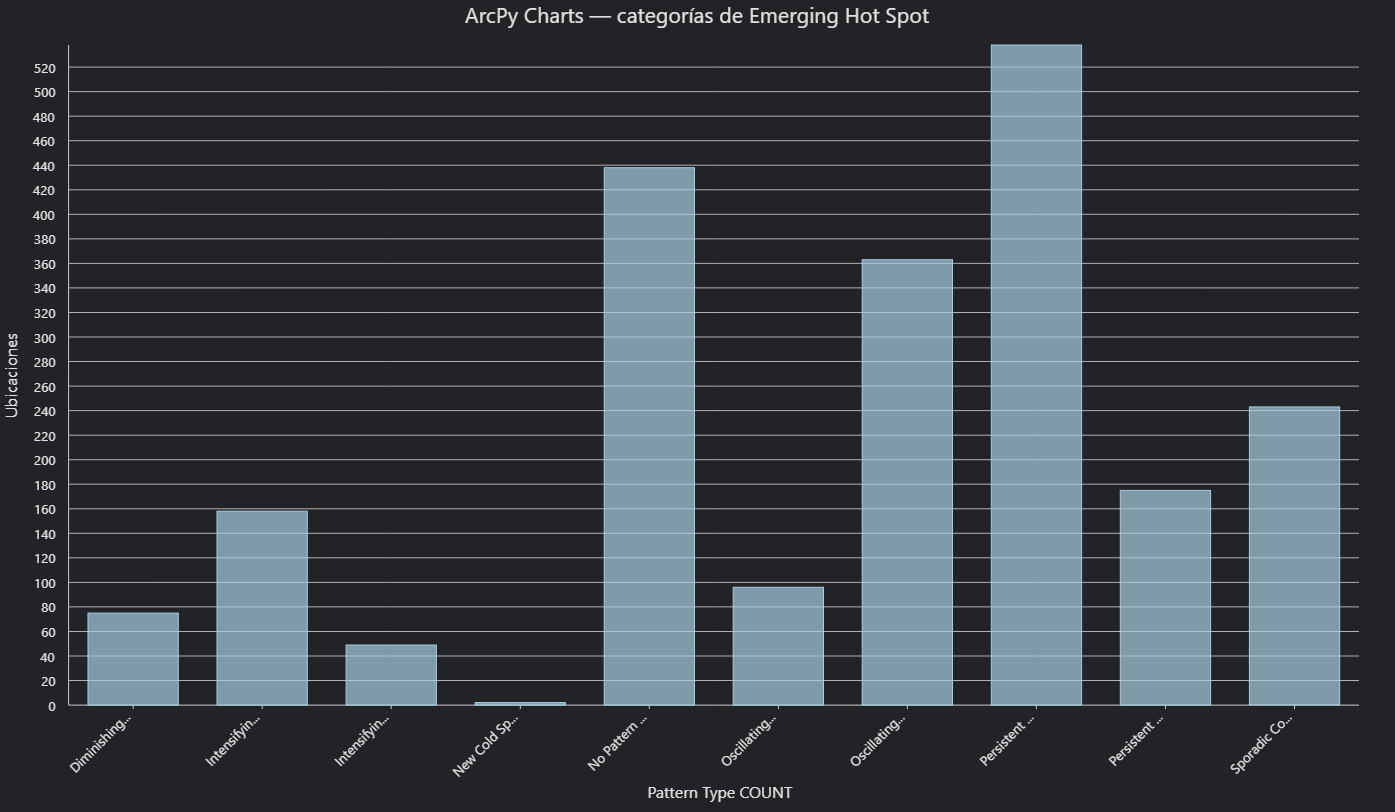

In [12]:
# Cuenta ubicaciones por patrón y exporta el gráfico de esta ejecución.
bar_emerging = arcpy.charts.Bar(x='PATTERN', aggregation='COUNT', showNullCategory=True,
                                nullCategoryLabel='Sin categoría (nulo)', yTitle='Ubicaciones')
bar_emerging.dataSource = emerging_fc
bar_emerging.title = 'ArcPy Charts — categorías de Emerging Hot Spot'
bar_emerging.exportToPNG(str(OUT_DIR / 'arcpy_chart_emerging_hotspot_patrones.png'), 1400, 820)

display(Image(filename=str(OUT_DIR / 'arcpy_chart_emerging_hotspot_patrones.png')))

## 8. Histograma de conteos por bin del cubo

### Antes de ejecutar

La capa 3D contiene un campo `VALUE` que representa el conteo en cada bin. Un histograma permite ver la distribución de intensidad en los bins exportados.

### Después de ejecutar

Se exporta un histograma de conteos por bin: X es COUNT, Y frecuencia de bins en cada intervalo. La diferencia entre media y mediana ayuda a reconocer asimetría sin concluir causalidad. El recuento impreso distingue ceros (bins observados sin eventos) de nulos (no disponibles); estos últimos no son ceros y quedan fuera de la distribución numérica. El CSV 3D conserva el límite histórico de 5000 filas, pero el histograma lee la capa completa exportada por la herramienta, no ese CSV truncado.

Bins exportados: 26390 | COUNT cero: 5302 | COUNT nulo: 0


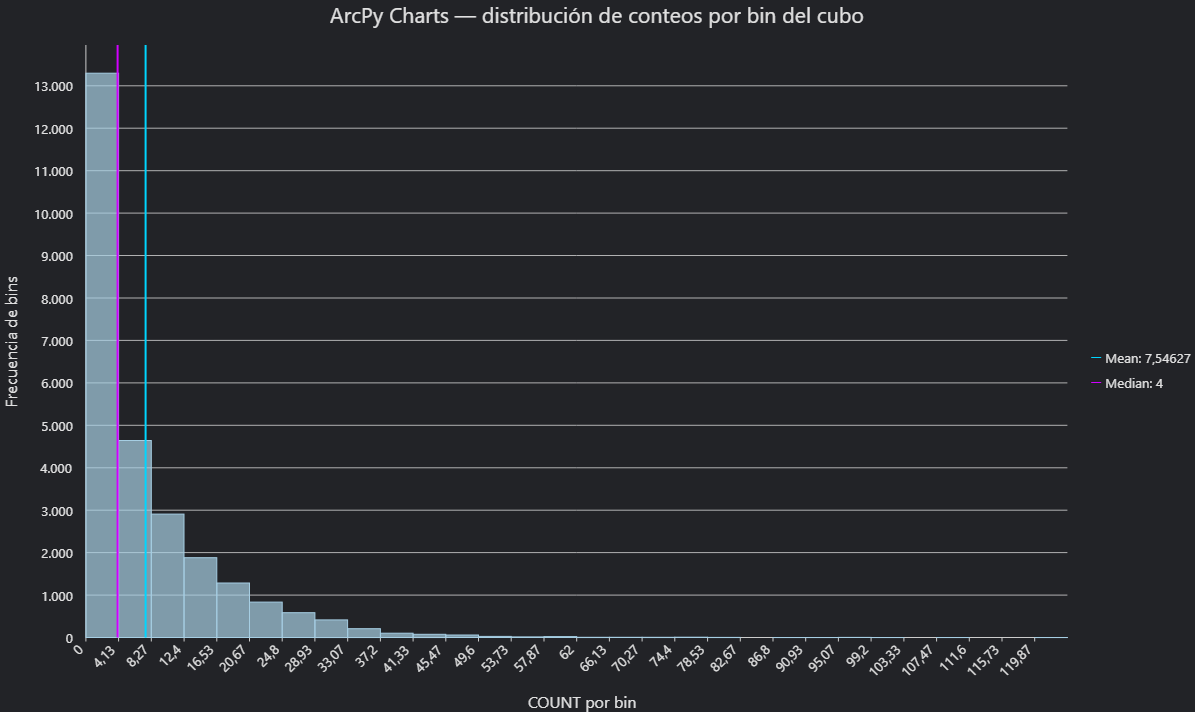

In [13]:
# Examina la distribución de conteos por bin, no una distribución de eventos individuales.
with arcpy.da.SearchCursor(cube_3d_counts, ['VALUE']) as cursor:
    values = Counter(value for (value,) in cursor)
print('Bins exportados:', sum(values.values()), '| COUNT cero:', values[0], '| COUNT nulo:', values[None])
hist_bins = arcpy.charts.Histogram(x='VALUE', binCount=30, showMean=True, showMedian=True,
                                     xTitle='COUNT por bin', yTitle='Frecuencia de bins')
hist_bins.dataSource = cube_3d_counts
hist_bins.title = 'ArcPy Charts — distribución de conteos por bin del cubo'
hist_bins.exportToPNG(str(OUT_DIR / 'arcpy_chart_hist_bins_cubo.png'), 1200, 720)

display(Image(filename=str(OUT_DIR / 'arcpy_chart_hist_bins_cubo.png')))

**Lectura del histograma actual:** 26.390 bins exportados, 5.302 con cero y ninguno nulo. La media aproximada 7,546 supera la mediana 4: una cola derecha concentra conteos altos. El CSV de 5.000 filas no resume por sí solo toda esta distribución.

## 9. Contraste 2D: Optimized Hot Spot Analysis

### Qué hace

Ejecuta `OptimizedHotSpotAnalysis` sobre siniestros desde 2020.

### Por qué

Sirve como contraste 2D frente al análisis emergente: concentración acumulada versus historia temporal.

### Para qué

Para ver qué cambia cuando se ignora la secuencia temporal y se analiza una ventana reciente como mapa de hot/cold spots.

### Después de ejecutar

Se obtiene una capa de polígonos con campos `GiZScore`, `GiPValue`, `Gi_Bin` y `JOIN_COUNT`.

In [14]:
# Filtra en una capa temporal: no elimina registros de la entrada.
siniestros_2020 = 'siniestros_2020'
arcpy.management.MakeFeatureLayer(SINESTROS, siniestros_2020, "ANO_OCURRE >= 2020")
print('Siniestros 2020+:', arcpy.management.GetCount(siniestros_2020)[0])

optimized_fc = str(WORK_GDB / 'OptimizedHotSpot_Siniestros_2020plus')
arcpy.stats.OptimizedHotSpotAnalysis(siniestros_2020, optimized_fc)

print('Polígonos de salida:', arcpy.management.GetCount(optimized_fc)[0])
print(arcpy.GetMessages())

Siniestros 2020+: 40538


Polígonos de salida: 871
Start Time: jueves, 17 de septiembre de 2026 3:29:02 p. m.
Row Count = 871
Succeeded at jueves, 17 de septiembre de 2026 3:29:02 p. m. (Elapsed Time: 0.03 seconds)


## 10. Exportar y graficar bins de significancia Gi*

### Antes de ejecutar

`Gi_Bin` codifica niveles de significancia. Valores positivos indican hot spots; negativos indican cold spots; cero indica no significativo.

### Después de ejecutar

Se exportan tabla detallada, resumen por `Gi_Bin` y gráfico de barras.

{-3: 120, -2: 80, -1: 33, 0: 318, 1: 24, 2: 59, 3: 237}


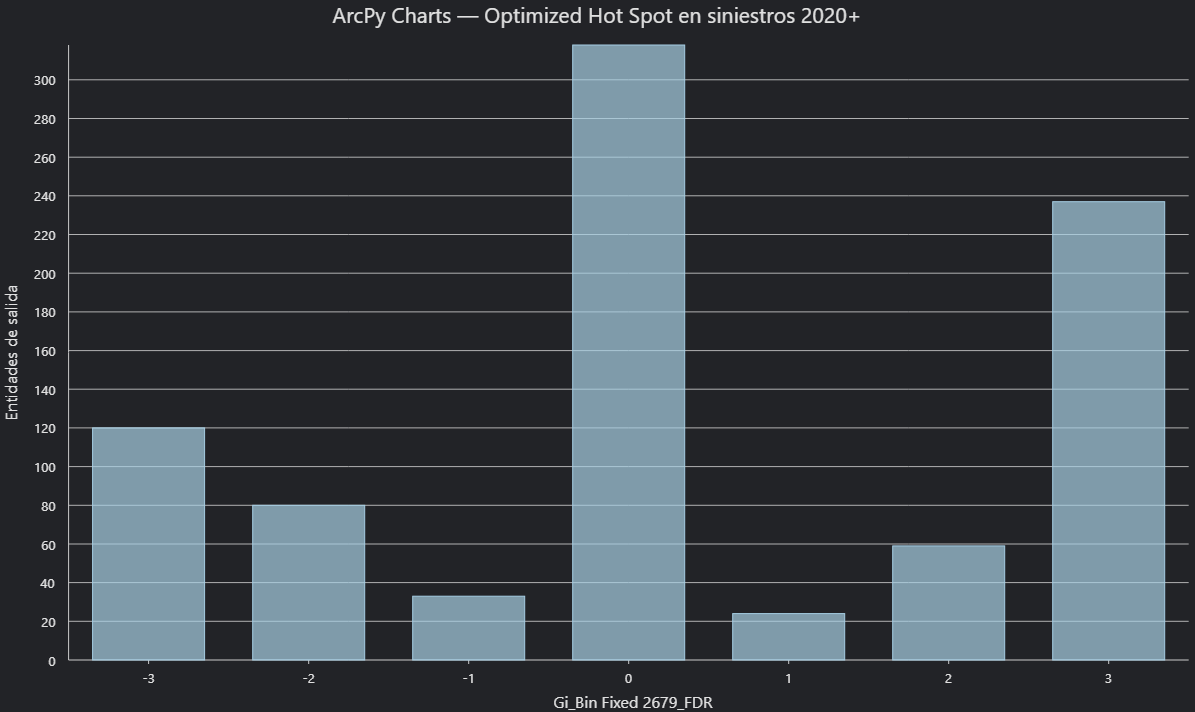

In [15]:
# Resume Gi_Bin y conserva tabla y gráfico dentro de OUT_DIR.
export_table(optimized_fc, OUT_DIR / 'tabla_optimized_hotspot_siniestros_2020plus.csv')

bin_counts = {}
with arcpy.da.SearchCursor(optimized_fc, ['Gi_Bin']) as cursor:
    for (bin_value,) in cursor:
        bin_counts[bin_value] = bin_counts.get(bin_value, 0) + 1

bin_csv = OUT_DIR / 'tabla_optimized_hotspot_siniestros_2020plus_bins.csv'
with open(bin_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Gi_Bin', 'Conteo'])
    for key, value in sorted(bin_counts.items(), key=lambda item: (item[0] is None, item[0] or 0)):
        writer.writerow([key, value])

bar_optimized = arcpy.charts.Bar(x='Gi_Bin', aggregation='COUNT', showNullCategory=True,
                                 nullCategoryLabel='Sin resultado (nulo)', yTitle='Entidades de salida')
bar_optimized.dataSource = optimized_fc
bar_optimized.title = 'ArcPy Charts — Optimized Hot Spot en siniestros 2020+'
bar_optimized.exportToPNG(str(OUT_DIR / 'arcpy_chart_optimized_hotspot_siniestros_2020plus.png'), 1200, 720)

print(bin_counts)
display(Image(filename=str(OUT_DIR / 'arcpy_chart_optimized_hotspot_siniestros_2020plus.png')))

**Lectura de OHA actual:** 40.538 siniestros de 2020+ produjeron 871 polígonos: 553 significativos y 318 no significativos. Gi_Bin -3/-2/-1/0/1/2/3 cuenta 120/80/33/318/24/59/237 entidades. Este universo difiere de las 2.137 ubicaciones de Emerging.

## 11. Salidas cartográficas de la práctica

### Qué hace

Exporta mapas nuevos de siniestros recientes, ubicaciones con datos y tendencias. Cada uno usa sus entidades locales y una leyenda nativa, sin imágenes de otra ejecución. Las salidas actuales están incrustadas en las celdas siguientes.

### Por qué

Los gráficos de barras e histogramas explican distribución y categorías, pero la práctica necesita evidencia espacial para comparar dónde aparecen los patrones.

### Para qué

Para dejar en el notebook una lectura visual similar a la clase anterior: puntos de entrada, tendencias del cubo, patrones emergentes y hot spots 2D.

### Cómo interpretar

- El mapa de siniestros 2020+ muestra densidad visual de incidentes recientes.
- El mapa de tendencias del cubo resume tendencias por ubicación.
- El mapa de Emerging Hot Spot clasifica historias espacio-temporales.
- El mapa de Optimized Hot Spot muestra concentración 2D reciente sin historia temporal.


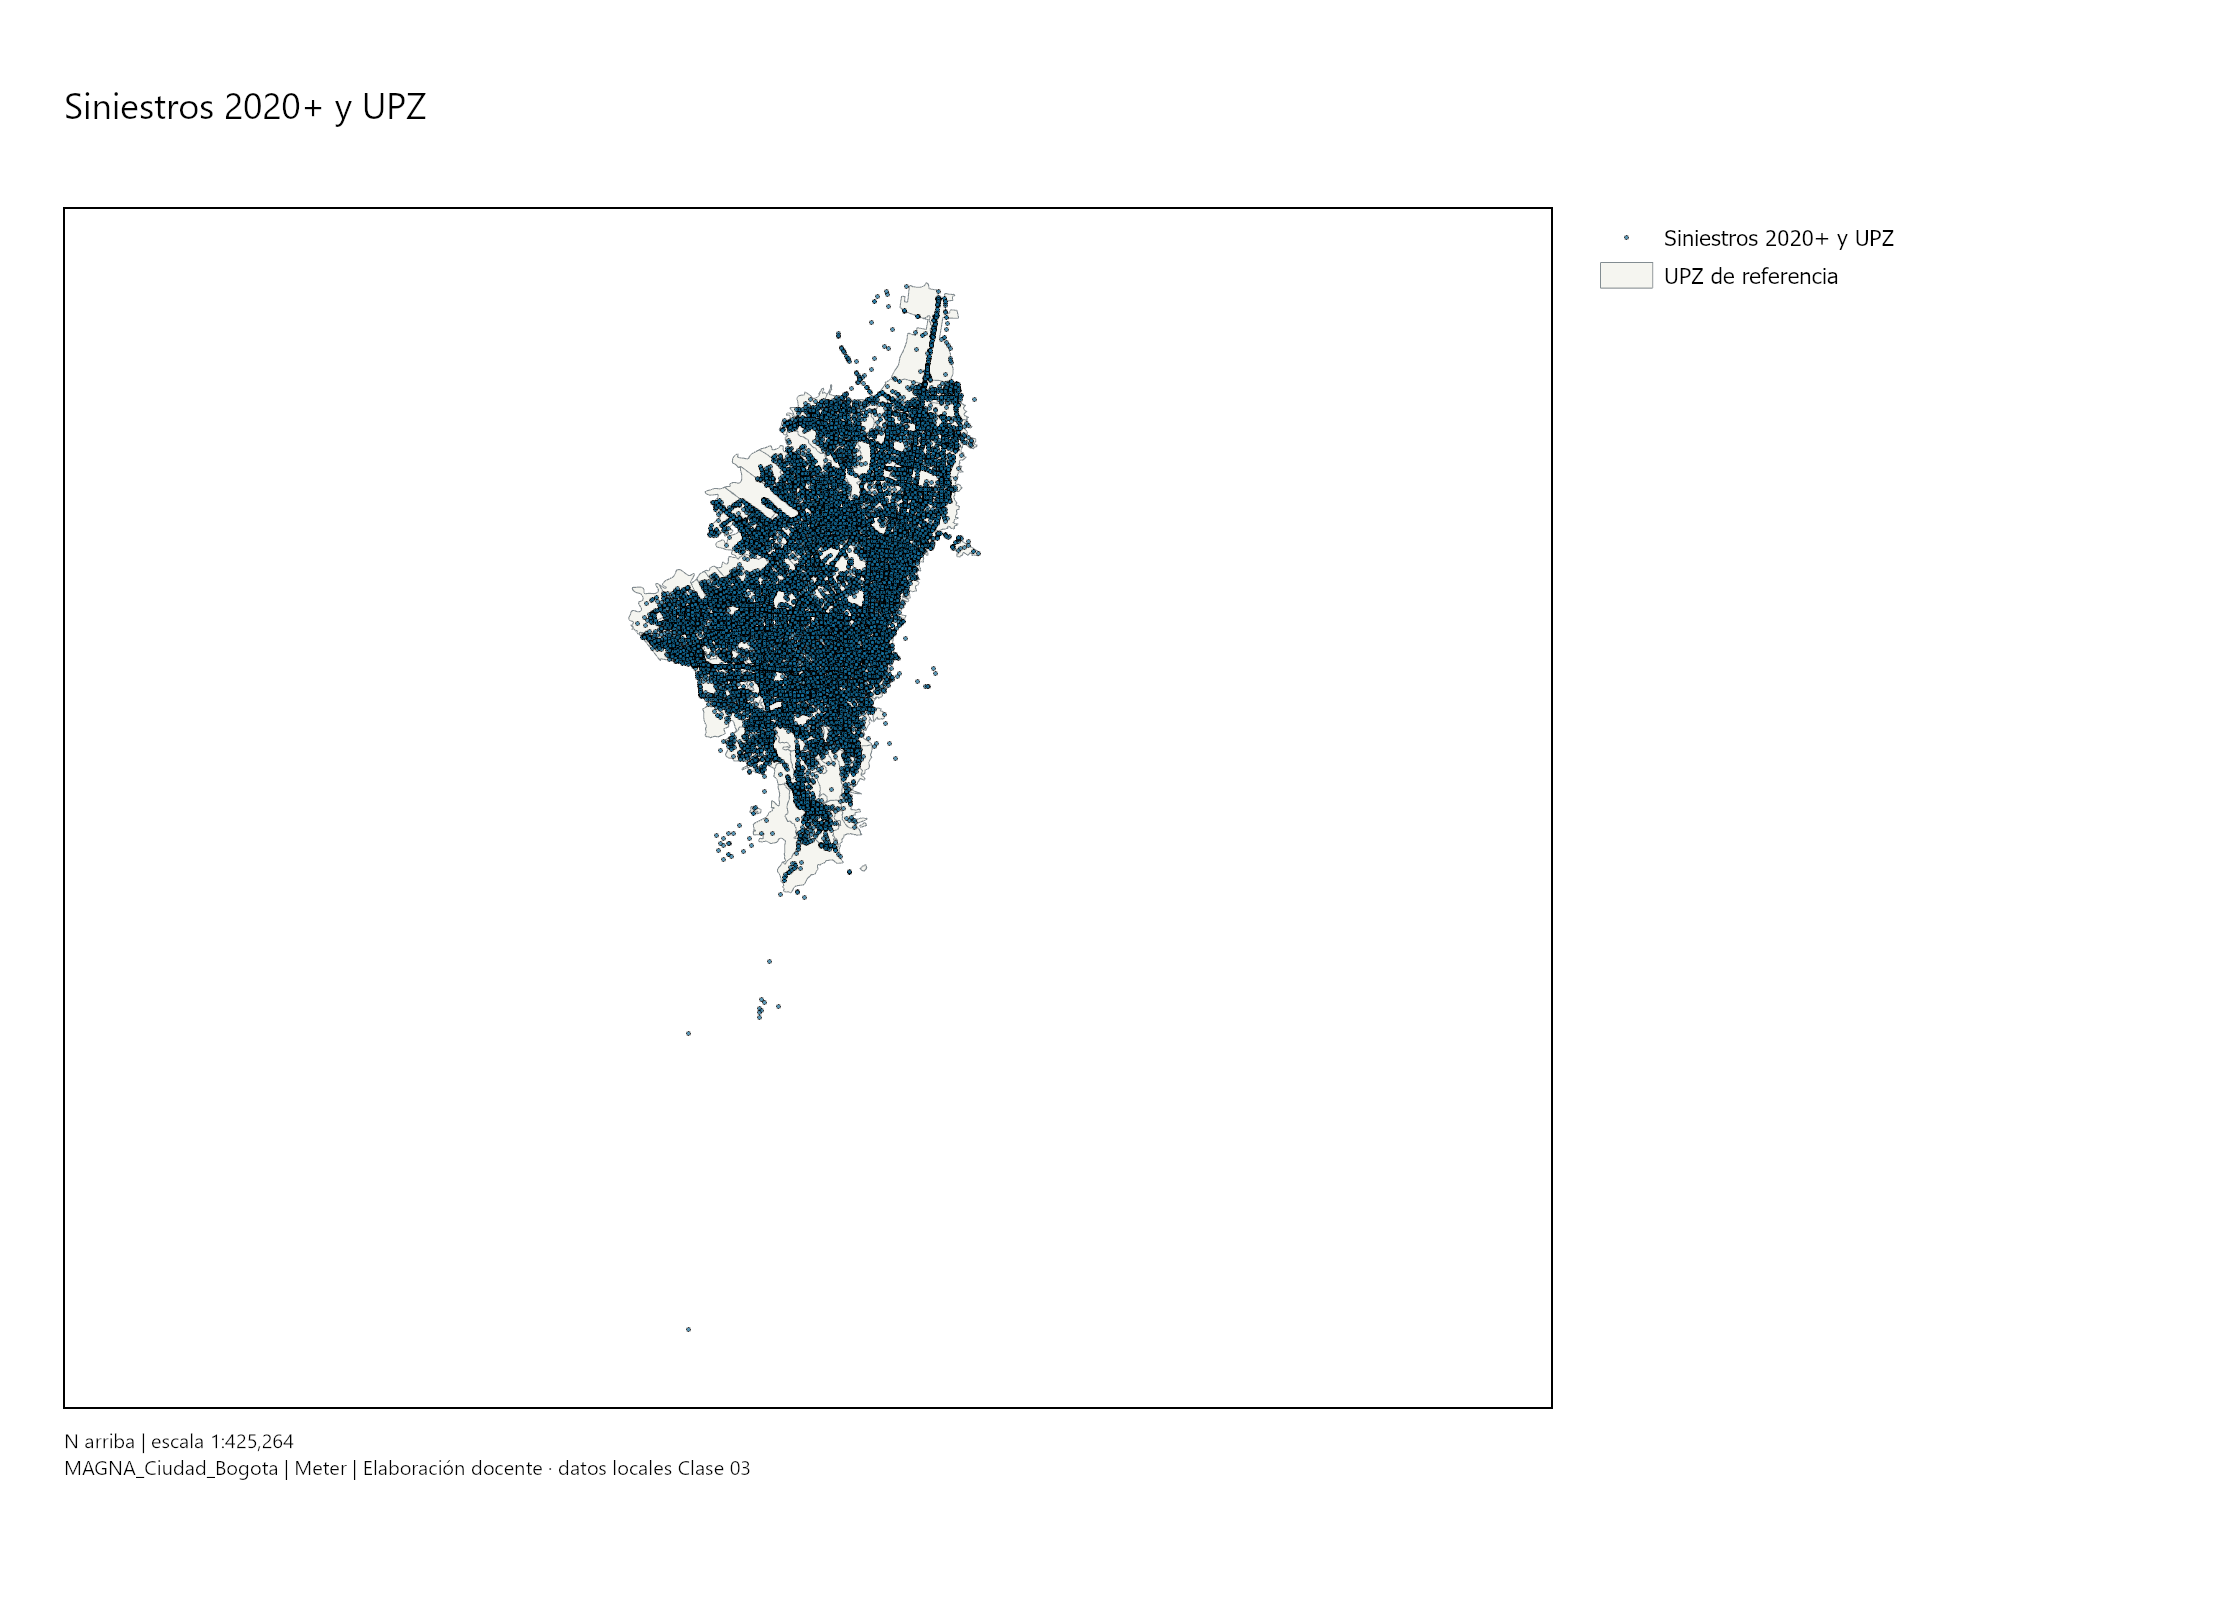

CRS: MAGNA_Ciudad_Bogota | unidades: Meter | entidades: 40538


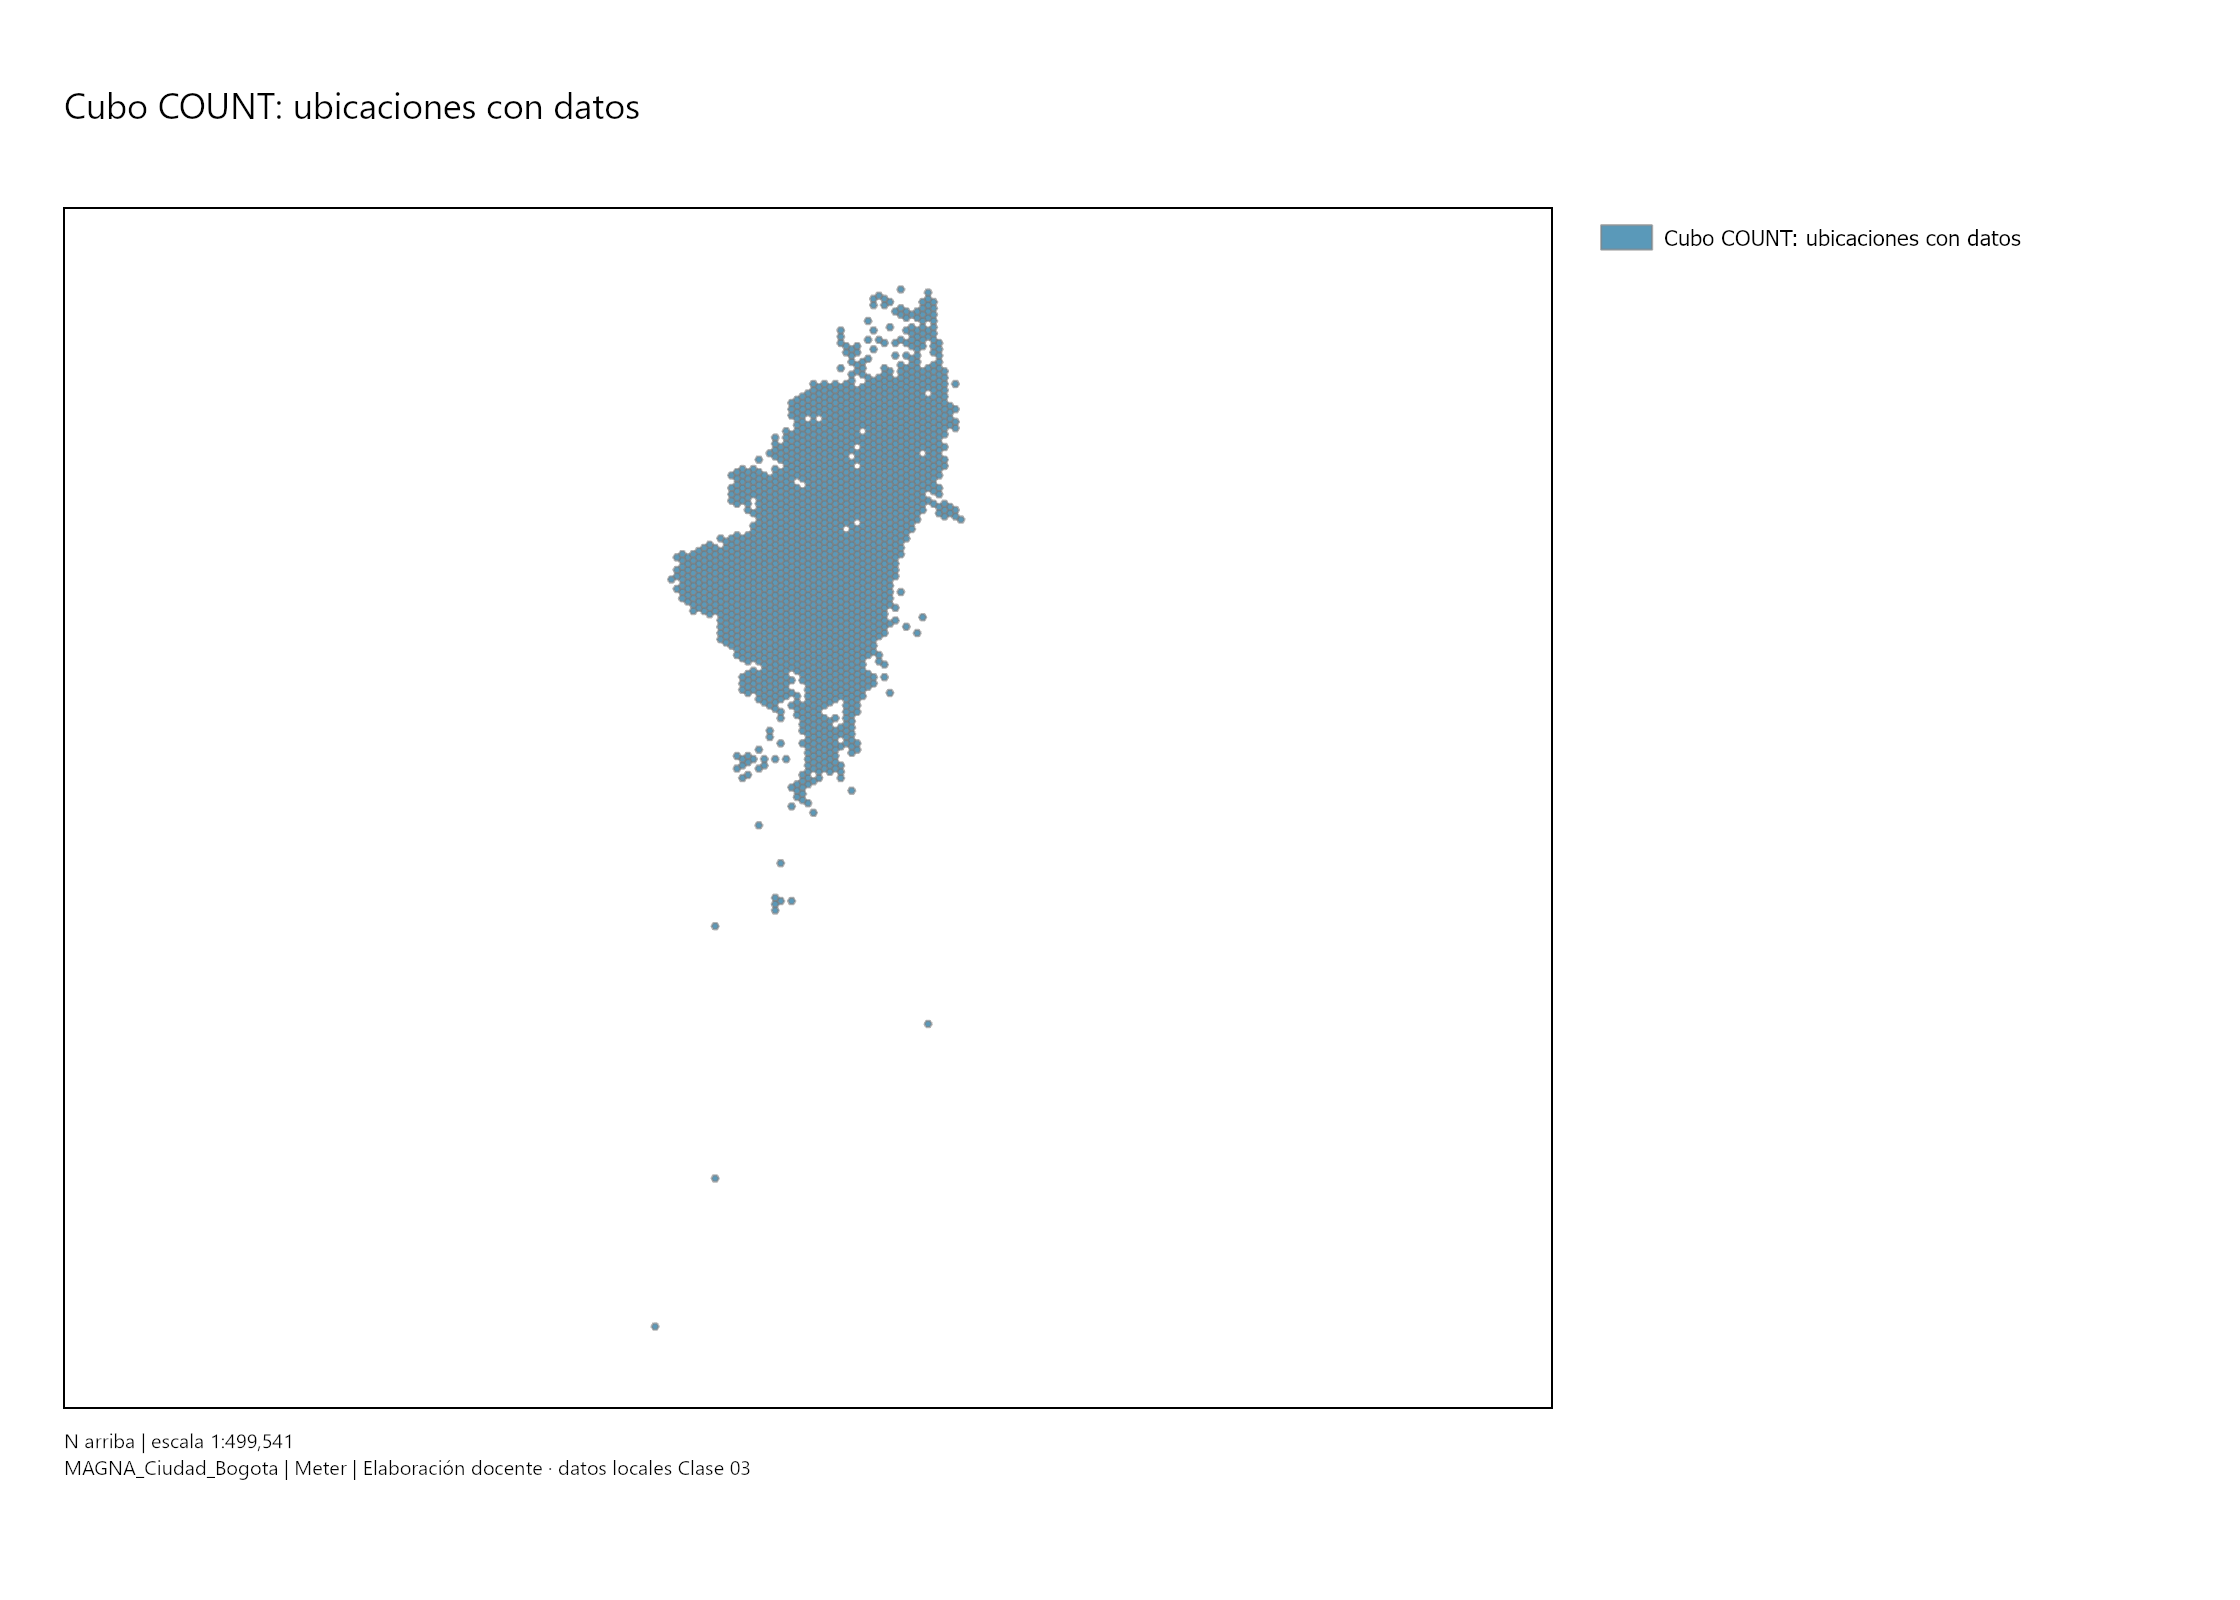

CRS: MAGNA_Ciudad_Bogota | unidades: Meter | entidades: 1885


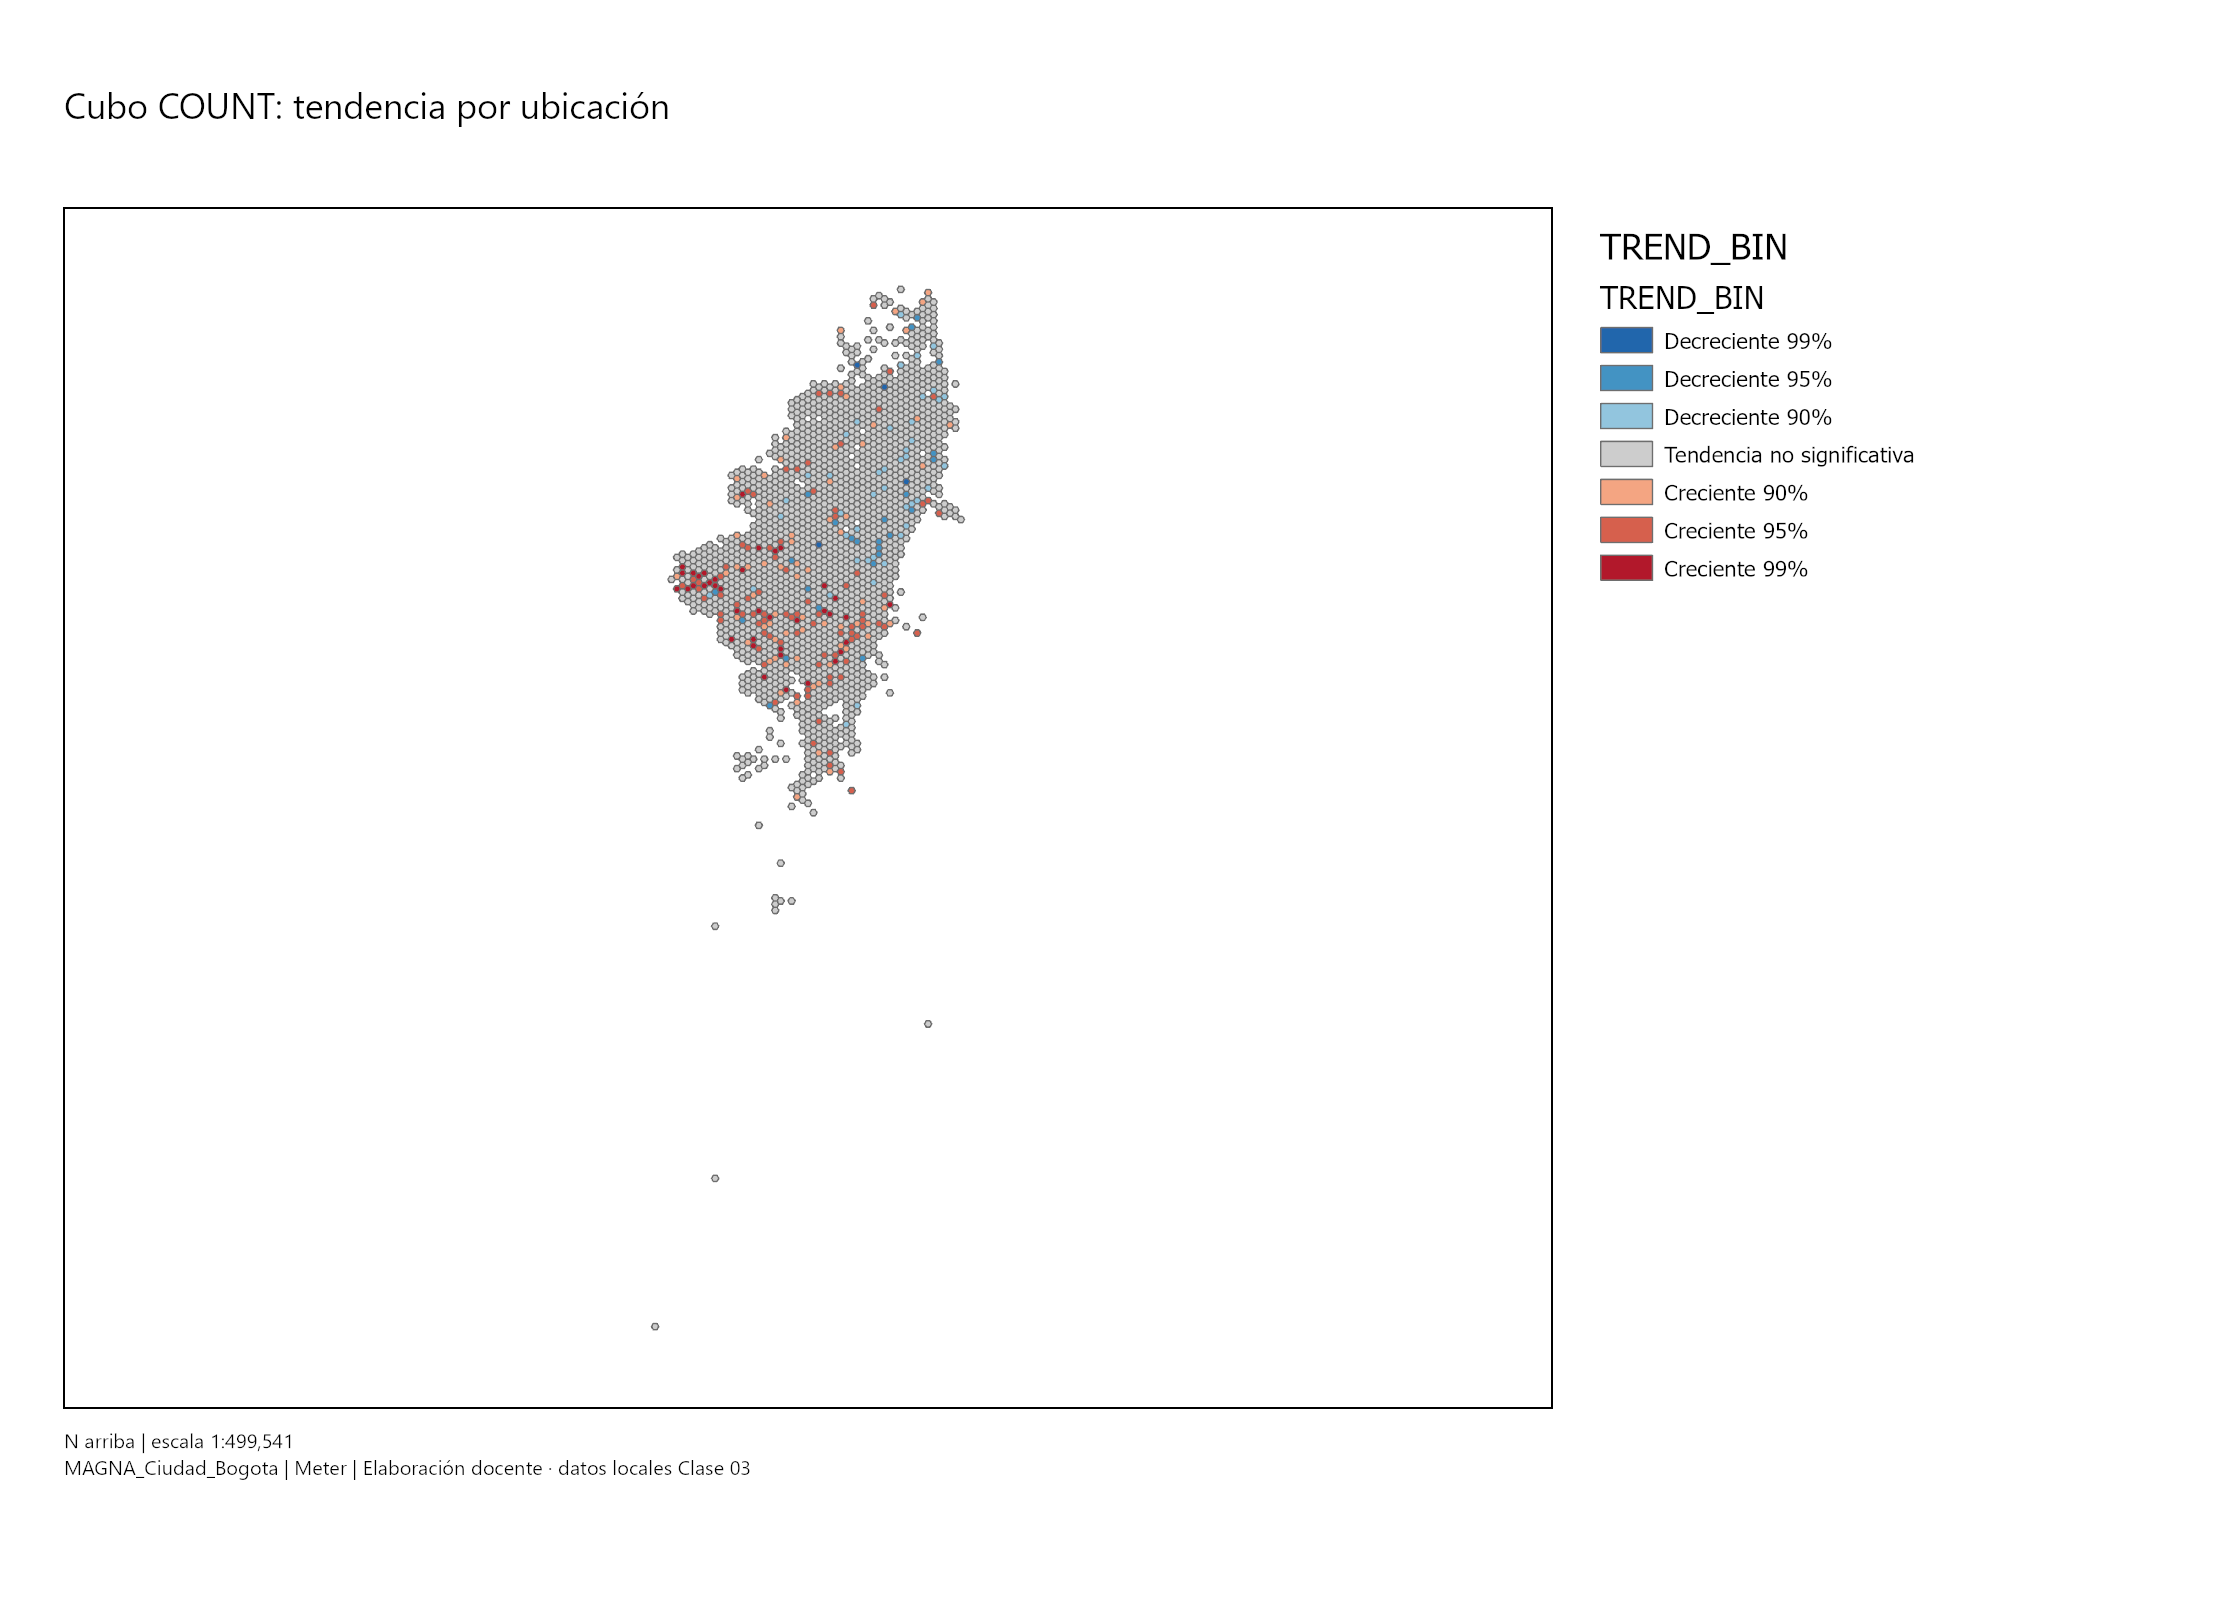

CRS: MAGNA_Ciudad_Bogota | unidades: Meter | entidades: 1885
Ubicaciones: cobertura del cubo, no intensidad. Tendencias: dirección y confianza, no Gi*.


In [16]:
# Exporta la selección a una copia cartográfica; el filtro y el modelo no cambian.
siniestros_2020_mapa = str(WORK_GDB / 'Siniestros_2020_cartografia')
arcpy.management.CopyFeatures(siniestros_2020, siniestros_2020_mapa)
native_map(siniestros_2020_mapa, 'mapa_siniestros_2020_upz', 'Siniestros 2020+ y UPZ', context=upz_mapa)
native_map(cube_2d_locations, 'mapa_cubo_ubicaciones', 'Cubo COUNT: ubicaciones con datos')
native_map(cube_2d_trends, 'mapa_cubo_tendencias', 'Cubo COUNT: tendencia por ubicación', 'TREND_BIN')
print('Ubicaciones: cobertura del cubo, no intensidad. Tendencias: dirección y confianza, no Gi*.')


**Lectura de tendencias actuales:** TREND_BIN está presente en 1.885 ubicaciones; 1.620 no significativas, 192 con tendencia creciente y 73 decreciente. Describen COUNT en el tiempo, no Gi*.

## 12. Salidas ArcGIS Pro con leyenda

### Qué hace

Genera mapas de patrones emergentes y Gi* y una escena local del cubo COUNT usando `arcpy.mp`, layout, map frame y leyenda. En 3D la altura geométrica representa la secuencia temporal construida por la herramienta, no elevación del terreno ni magnitud de COUNT: el conteo se expresa mediante color. La cámara oblicua permite ver apilamiento, con oclusión y perspectiva; el histograma anterior complementa esa lectura. La cobertura temporal exacta se lee en el reporte del cubo y en los atributos exportados, no en una conversión inventada de metros a fechas.

`TREND_BIN` describe tendencia temporal, no concentración Gi*. `PATTERN` distingue historias; color cálido/frío indica dirección, no severidad. `Gi_Bin` expresa significancia corregida por FDR: ±1, ±2, ±3 corresponden a 90%, 95%, 99%; cero significa no significativo, nunca nulo ni ausencia de eventos. Un mapa y sus barras deben leerse juntos. La escena verifica Z no constante y cámara local; si ArcGIS no puede producirla, se registra el bloqueo y continúan los casos 2D. Un PNG exportado aún requiere inspección visual, especialmente de leyendas y oclusión.

### Por qué

Los gráficos `arcpy.charts` resumen categorías y distribuciones, pero no sustituyen un mapa de análisis con simbología y leyenda. En las clases anteriores el notebook dejaba evidencia cartográfica exportada desde ArcGIS Pro; esta sección deja el mismo tipo de evidencia para la Clase 03.

### Para qué

Para revisar espacialmente dónde están las tendencias del cubo, los patrones emergentes y el contraste 2D de hot spots optimizados.


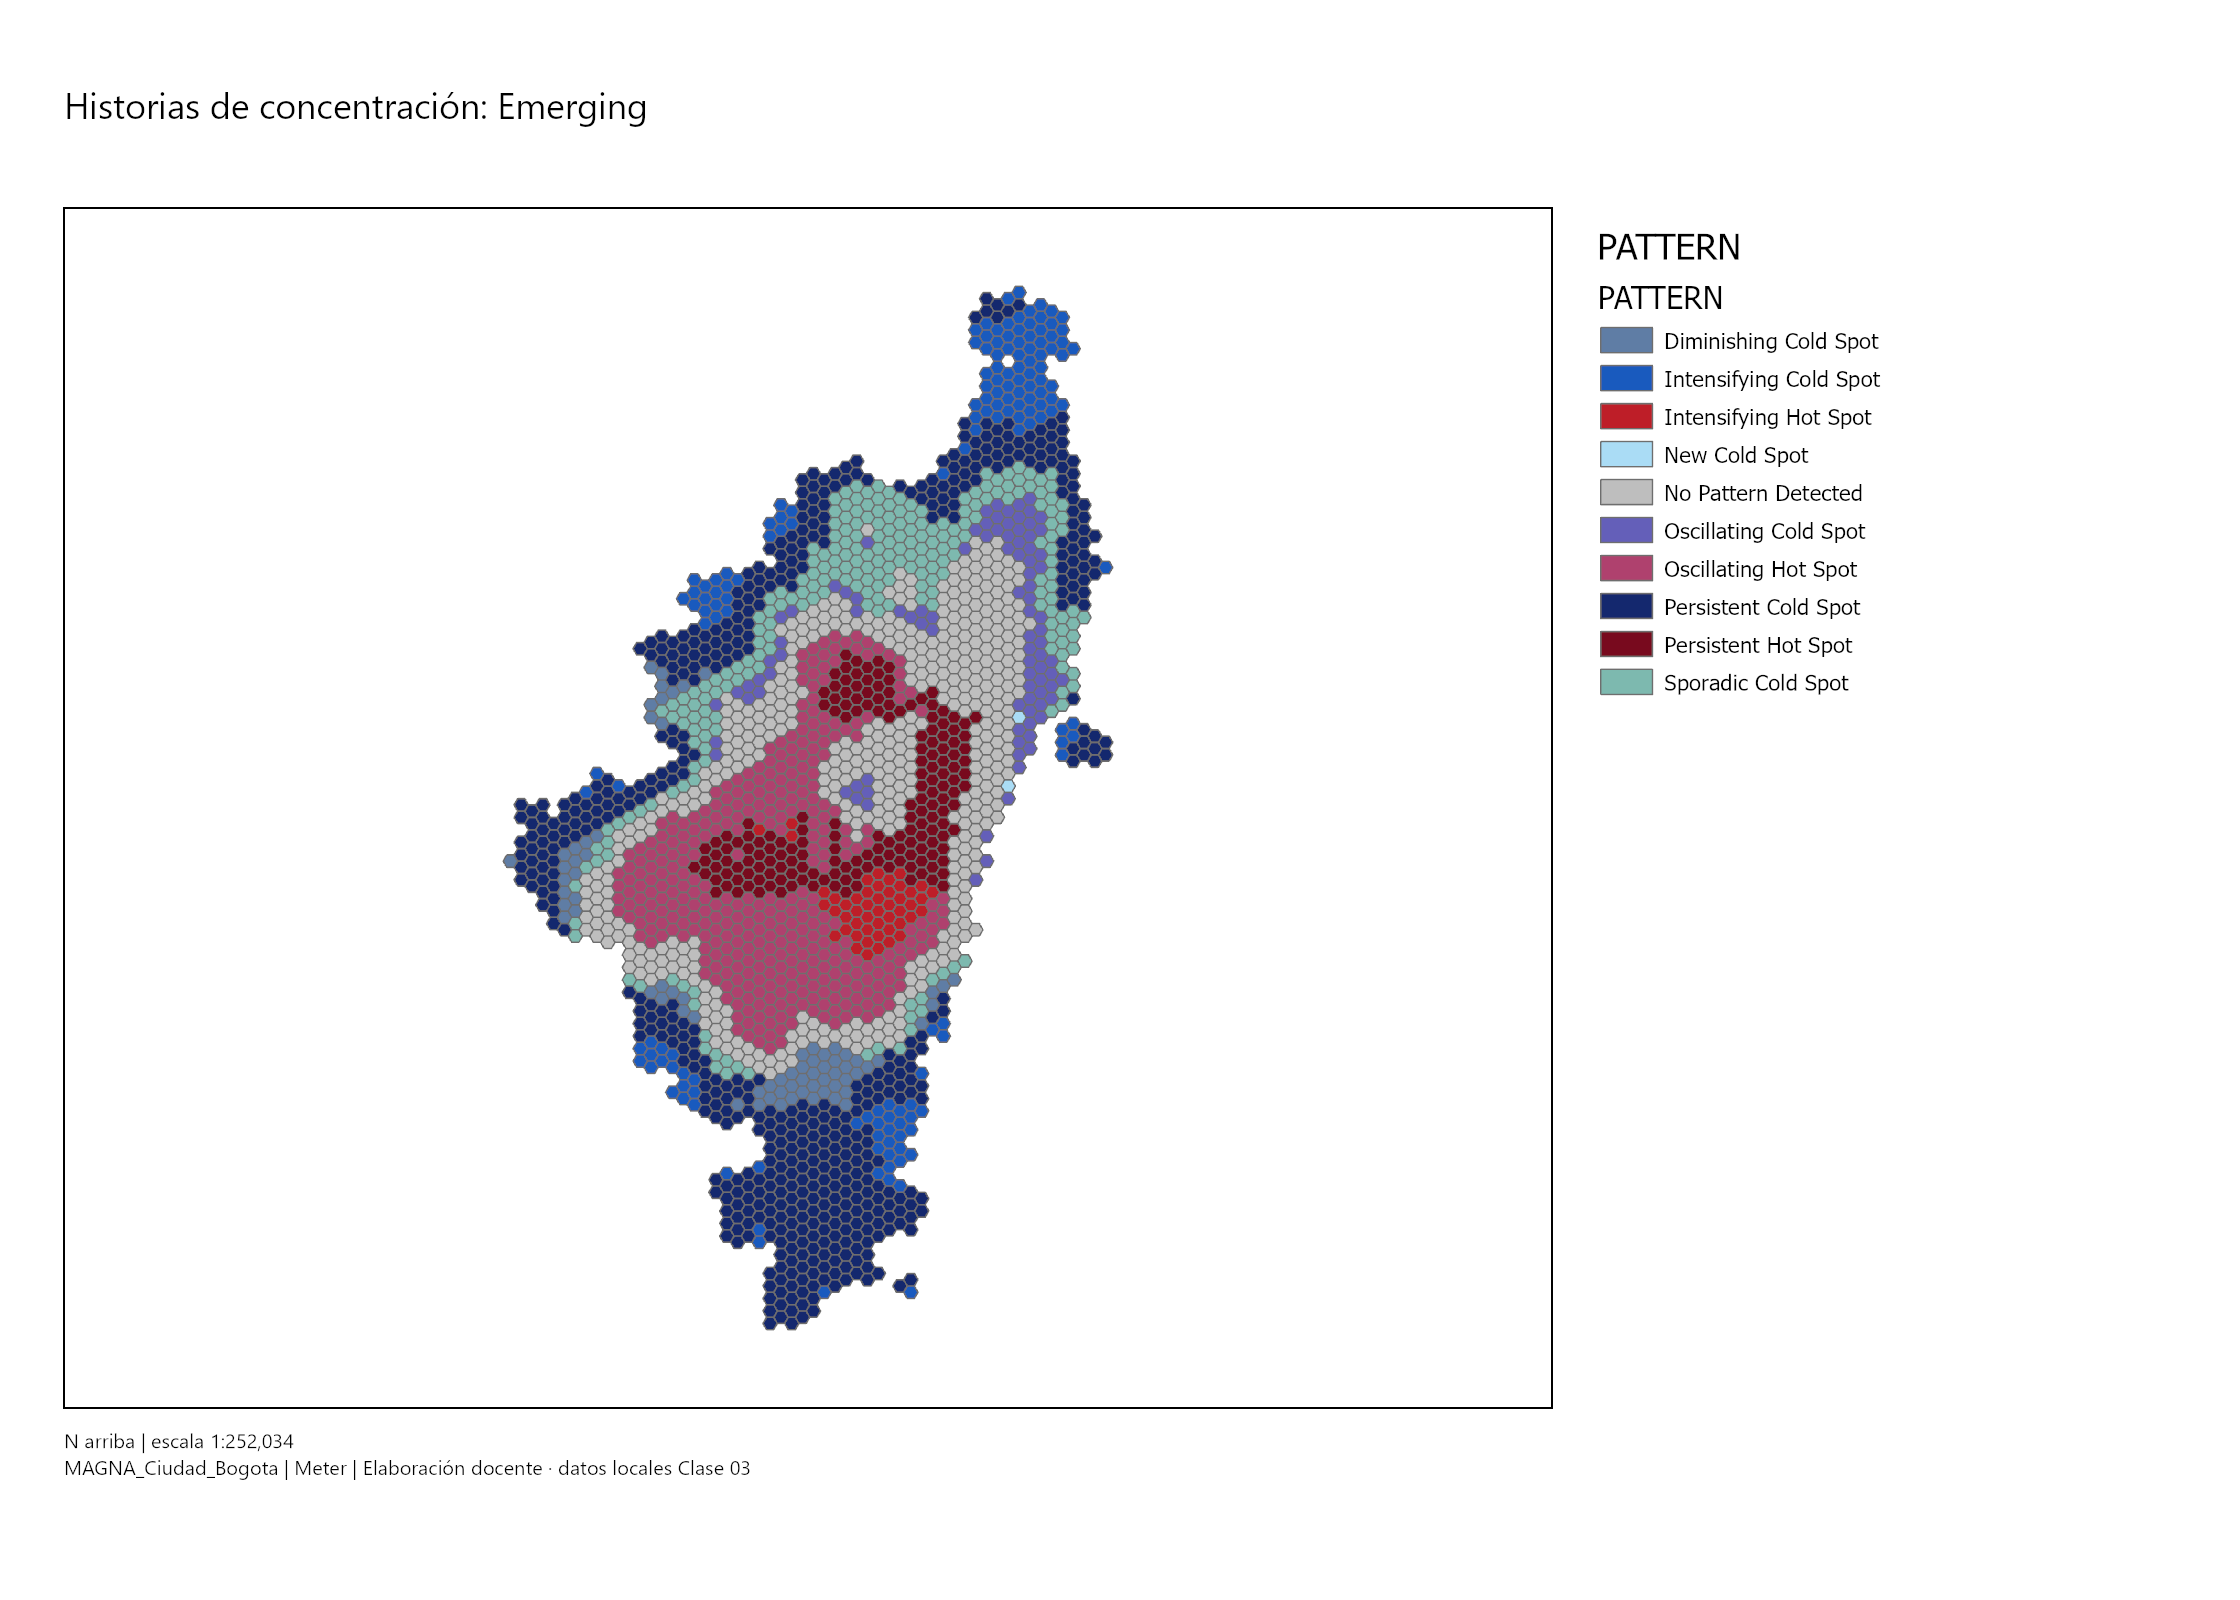

CRS: MAGNA_Ciudad_Bogota | unidades: Meter | entidades: 2137


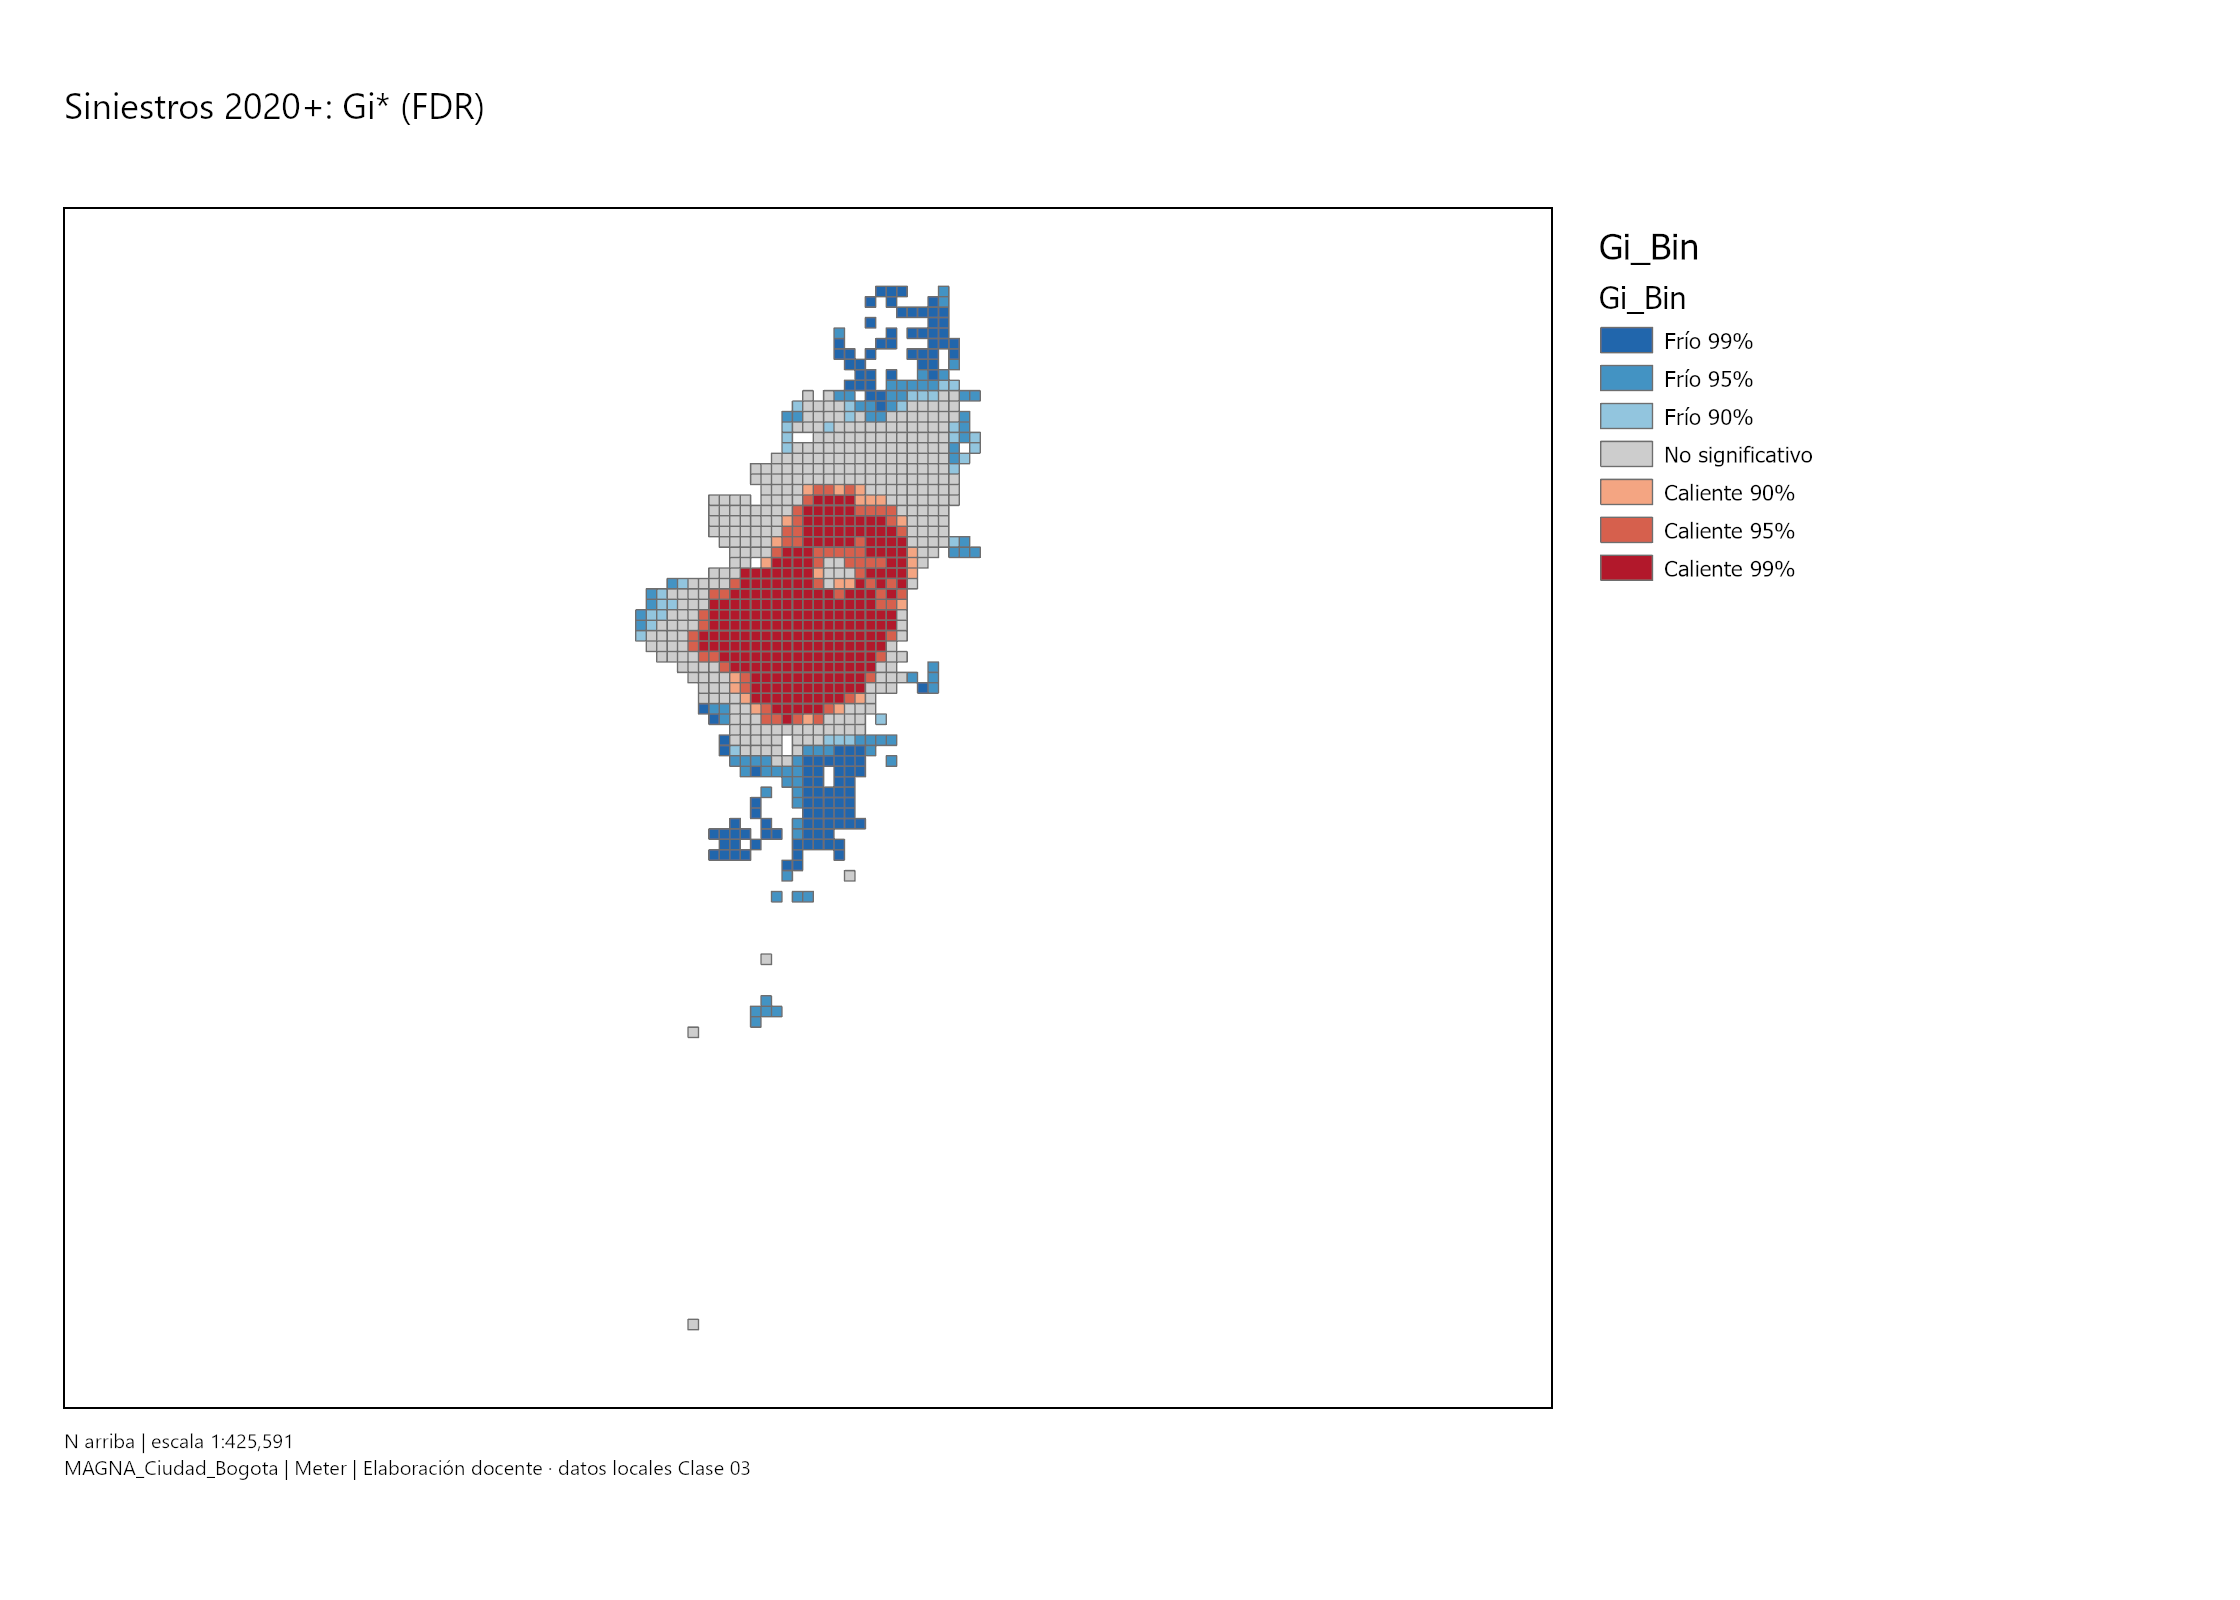

CRS: MAGNA_Ciudad_Bogota | unidades: Meter | entidades: 871


Rango Z observado del eje temporal: 0.0 750.5553000000073 | no es altitud del terreno


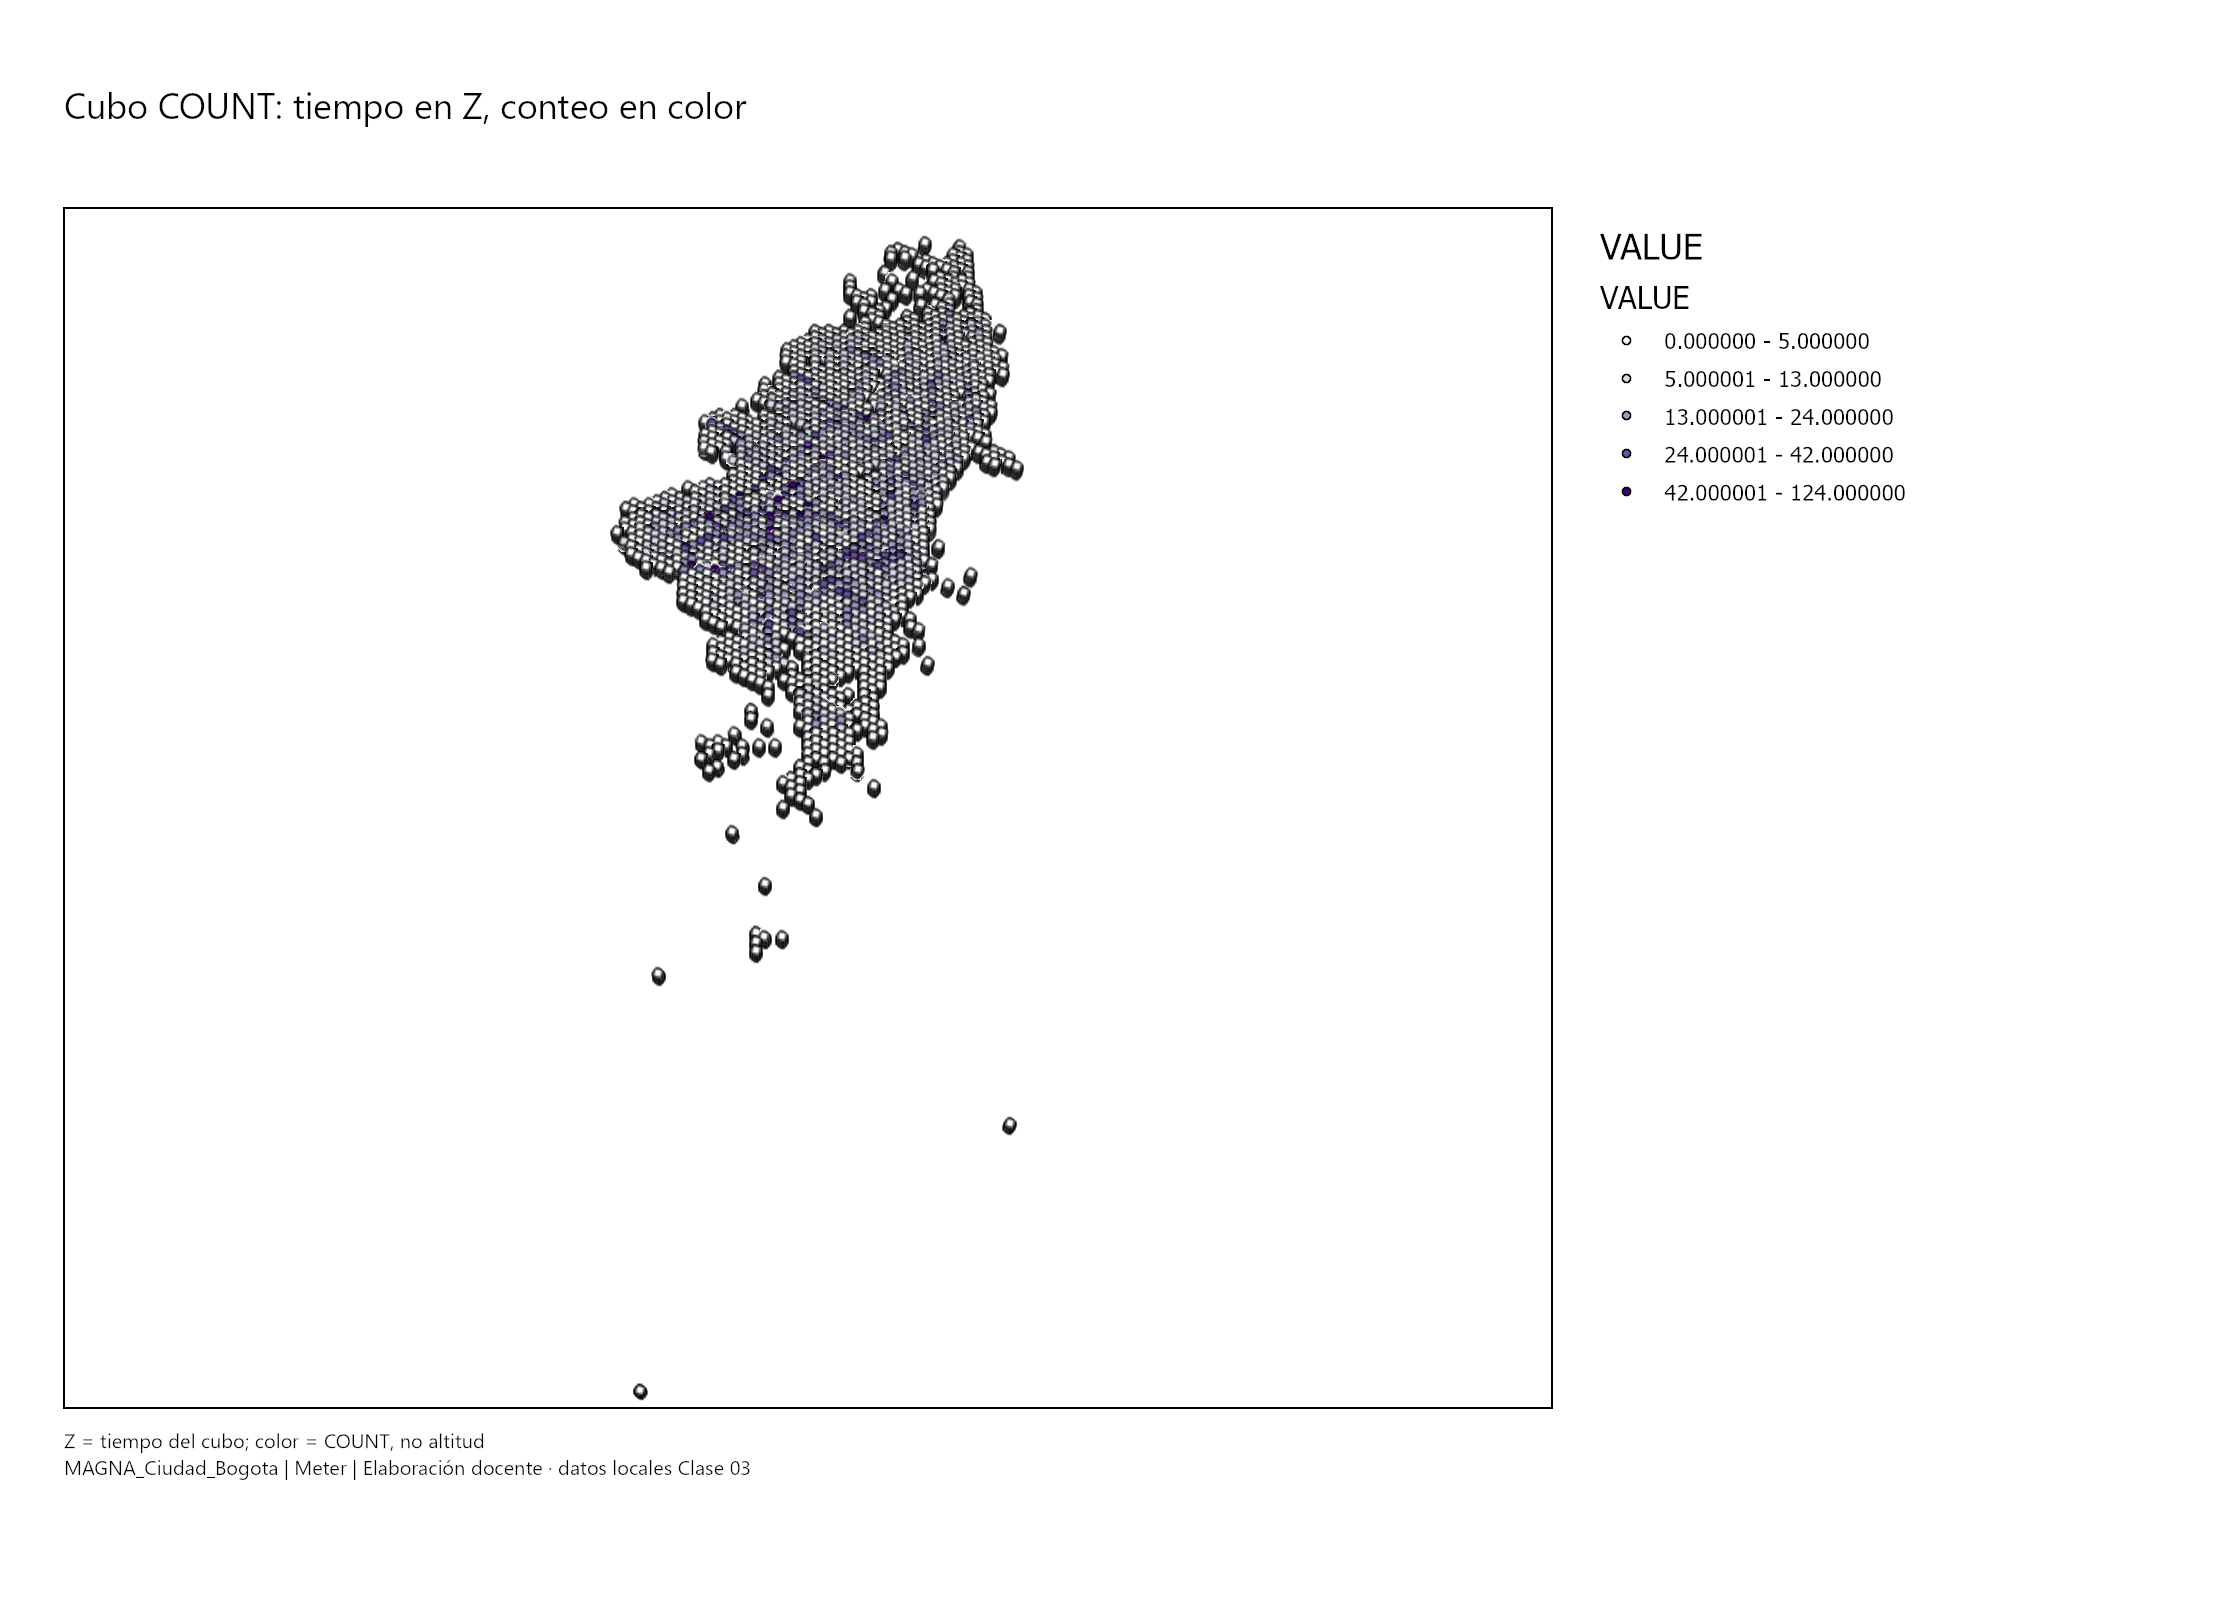

CRS: MAGNA_Ciudad_Bogota | unidades: Meter | entidades: 26390


In [17]:
# Categorías espaciales actuales, conservando las barras y CSV anteriores.
native_map(emerging_fc, 'arcgis_mapa_emerging_hotspot_patrones_leyenda', 'Historias de concentración: Emerging', 'PATTERN')
native_map(optimized_fc, 'arcgis_mapa_optimized_hotspot_2020plus_leyenda', 'Siniestros 2020+: Gi* (FDR)', 'Gi_Bin')
try:
    # Valida el eje Z de las entidades 3D antes de intentar una escena auténtica.
    if not arcpy.Describe(cube_3d_counts).hasZ:
        raise RuntimeError('La salida del cubo no tiene coordenadas Z.')
    z_min, z_max, invalid_z = math.inf, -math.inf, 0
    with arcpy.da.SearchCursor(cube_3d_counts, ['SHAPE@']) as cursor:
        for (geometry,) in cursor:
            low = geometry.extent.ZMin if geometry else None
            high = geometry.extent.ZMax if geometry else None
            if low is None or high is None or not math.isfinite(low) or not math.isfinite(high):
                invalid_z += 1
            else:
                z_min, z_max = min(z_min, low), max(z_max, high)
    if invalid_z or not z_max > z_min:
        raise RuntimeError(f'Z inválida o constante: {invalid_z} geometrías; rango {z_min}, {z_max}.')
    print('Rango Z observado del eje temporal:', z_min, z_max, '| no es altitud del terreno')
    native_map(cube_3d_counts, 'escena_cubo_count_3d', 'Cubo COUNT: tiempo en Z, conteo en color', 'VALUE', scene=True)
except Exception as error:
    # Bloquea solo 3D, sin exportar un mapa plano como sustituto.
    visual_blocks.append('Escena 3D: ' + str(error))
    print('BLOQUEO 3D — requiere resolver antes de completar la práctica:', error)


**Lectura de los mapas anteriores:** Emerging y Gi* 2020+ clasifican preguntas y universos distintos. La escena tiene cámara LOCAL, inclinación -60 grados y Z finita; Z geométrica temporal abarca 0-750,5553. Símbolos y bordes se superponen y dificultan separar los 14 niveles/colores en la vista general. No deduzca trayectorias individuales del PNG; consulte APRX y tablas. No se transformó ni exageró Z de los datos.

## 13. Caso complementario: Optimized Hot Spot para colegios

### Qué hace

Documenta **Optimized Hot Spot Analysis** sobre `Colegios_Colombia_CollectEvents`, preparado histórico de la Clase 14 fuente, migrado a `99 - Recursos/datos/clase_03/entradas.gdb`.

### Por qué

En la grabación se retomó el caso de colegios para mostrar que Optimized Hot Spot puede calcular una escala de análisis y producir hot/cold spots sin pasar por un cubo espacio-temporal.

### Para qué

Comparar la lectura 2D de concentración escolar con la autocorrelación incremental vista en la clase anterior. En la ejecución histórica de la fuente, la herramienta encontró una distancia óptima aproximada de **16,6 km** para `ICOUNT` sobre colegios agregados.

`ICOUNT` es el peso del preparado Collect Events: una fila representa una ubicación agregada, no necesariamente un colegio. OHA analiza esos pesos; las barras Gi* posteriores cuentan entidades clasificadas, no suman colegios. Se imprimen por separado filas, suma de pesos no nulos, ceros y nulos: un cero no equivale a información faltante. No se recalculan ni corrigen pesos. La extensión nacional y el CRS observado condicionan la lectura cartográfica; una unidad métrica no elimina distorsión de distancias ni implica exposición comparable.

In [18]:
# Usa ICOUNT del preparado local de solo lectura; no repite Integrate ni CollectEvents.
colegios_collect = GDB / 'Colegios_Colombia_CollectEvents'
optimized_hotspot_colegios = WORK_GDB / 'OptimizedHotSpot_Colegios_CollectEvents'

arcpy.stats.OptimizedHotSpotAnalysis(str(colegios_collect), str(optimized_hotspot_colegios), 'ICOUNT')
print(arcpy.GetMessages())

print('Colegios Collect Events:', colegios_collect)
print('Salida Optimized Hot Spot:', optimized_hotspot_colegios)
print('Referencia histórica de la fuente, no resultado actual: distancia 16625.3004 m; significativas FDR 3627.')

Start Time: jueves, 17 de septiembre de 2026 3:29:30 p. m.

************************** Initial Data Assessment ***************************
Making sure there are enough weighted features for analysis....
    - There are 9911 valid input features.

Evaluating the Analysis Field values....
    - ICOUNT Properties:
        Min:        1.0000
        Max:       13.0000
        Mean:       1.0712
        Std. Dev.:  0.3462
Looking for locational outliers....
    - There were 98 outlier locations; these will not be used to compute the optimal fixed distance band.

***************************** Scale of Analysis ******************************
Looking for an optimal scale of analysis by assessing the intensity of clustering at increasing distances....
    - The optimal fixed distance band is based on peak clustering found at 16625.3004 meters

***************************** Hot Spot Analysis ******************************
Finding statistically significant clusters of high and low ICOUNT values..

Colegios agregados | filas de entrada: 9911 | suma ICOUNT: 10617 | nulos: 0 | ceros: 0


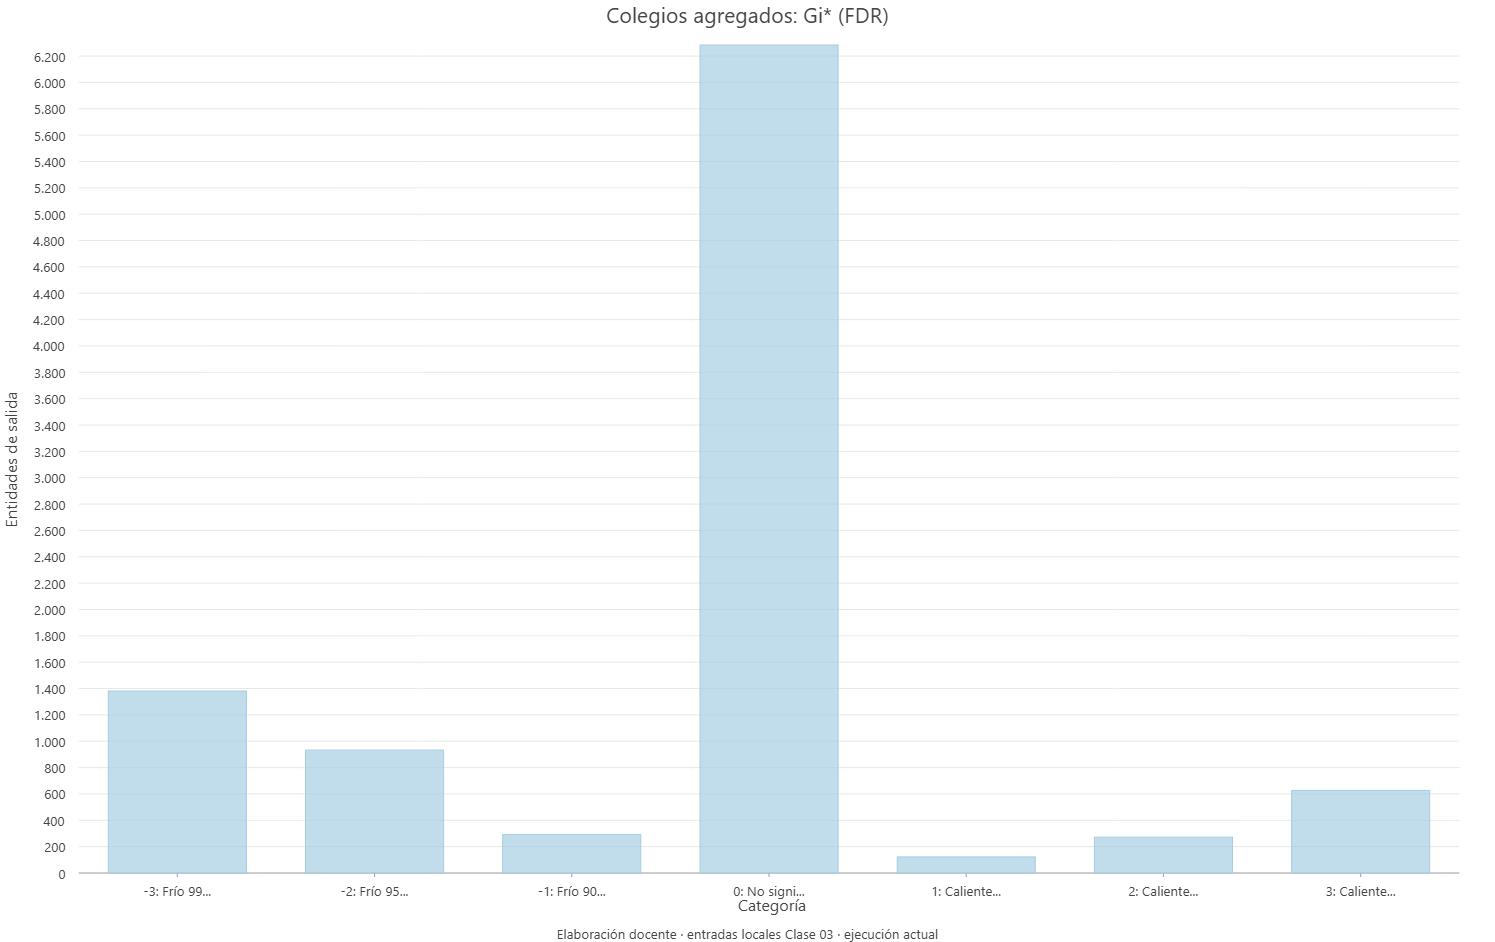

Colegios agregados: Gi* (FDR) {'0: No significativo': 6284, '1: Caliente 90%': 122, '2: Caliente 95%': 272, '-1: Frío 90%': 292, '-2: Frío 95%': 933, '3: Caliente 99%': 627, '-3: Frío 99%': 1381}


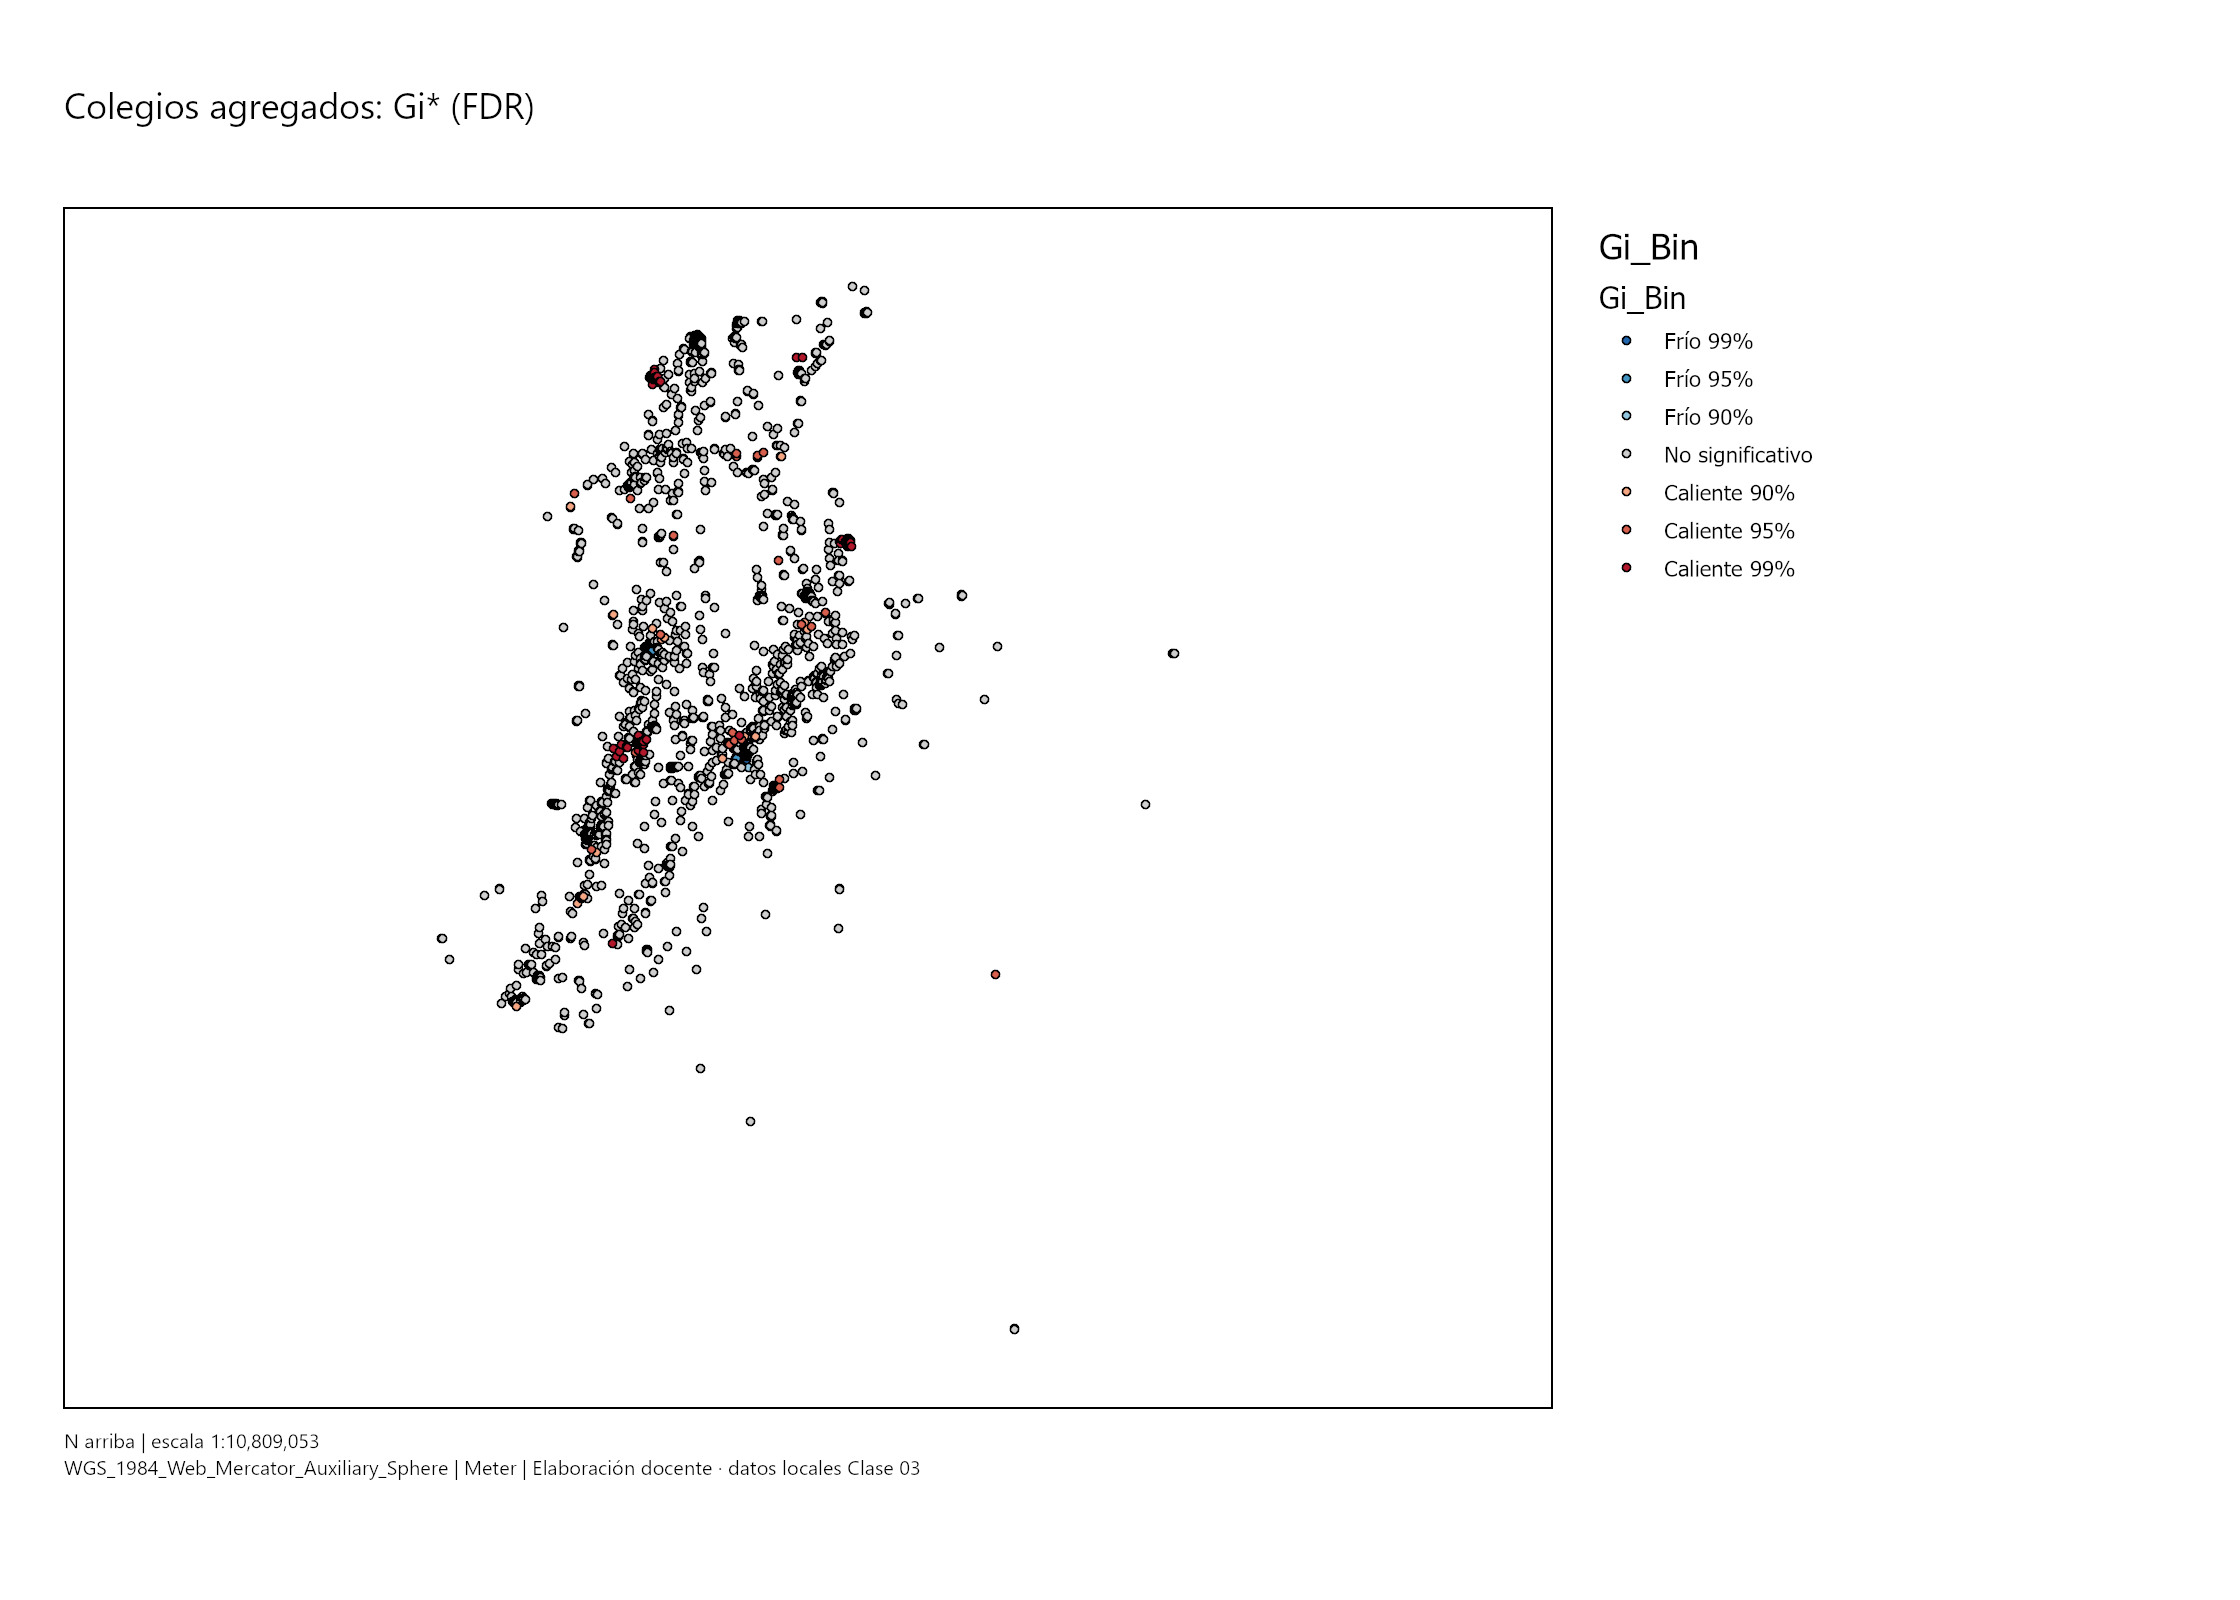

CRS: WGS_1984_Web_Mercator_Auxiliary_Sphere | unidades: Meter | entidades: 9911
Significativas: 3627 | no significativas: 6284 | sin resultado: 0
Barras = entidades por clase; no suman ICOUNT ni miden riesgo individual.


In [19]:
# Distingue ubicaciones agregadas, pesos ICOUNT y significancia de la salida.
def weighted_oha_visuals(source, result, name, title):
    weights = Counter()
    with arcpy.da.SearchCursor(str(source), ['ICOUNT']) as cursor:
        for (weight,) in cursor:
            weights[weight] += 1
    print(title, '| filas de entrada:', sum(weights.values()), '| suma ICOUNT:',
          sum(weight * rows for weight, rows in weights.items() if weight is not None),
          '| nulos:', weights[None], '| ceros:', weights[0])
    bins = Counter()
    with arcpy.da.SearchCursor(str(result), ['Gi_Bin']) as cursor:
        for (value,) in cursor:
            bins[value] += 1
    labels = {None if value is None else f'{value}: {gi_names.get(value, "Revisar código")}' : count
              for value, count in bins.items()}
    count_chart(labels, 'arcpy_chart_optimized_hotspot_' + name, title + ': Gi* (FDR)', 'Entidades de salida')
    native_map(result, 'arcgis_mapa_optimized_hotspot_' + name + '_leyenda', title + ': Gi* (FDR)', 'Gi_Bin')
    export_table(str(result), OUT_DIR / ('tabla_optimized_hotspot_' + name + '.csv'))
    print('Significativas:', sum(count for value, count in bins.items() if value in (-3,-2,-1,1,2,3)),
          '| no significativas:', bins[0], '| sin resultado:', bins[None])
    print('Barras = entidades por clase; no suman ICOUNT ni miden riesgo individual.')

weighted_oha_visuals(colegios_collect, optimized_hotspot_colegios, 'colegios', 'Colegios agregados')

**Lectura de colegios actuales:** 9.911 ubicaciones representan ICOUNT=10.617; 3.627 significativas con FDR y 6.284 no. Distancia automática 16.625,3004 m. La herramienta advirtió más de 1.000 vecinos para algunas entidades; 7,1 % tuvo menos de ocho. Estas advertencias y la distorsión EPSG:3857 limitan interpretar la escala como distancia de terreno uniforme.

## 14. Caso complementario: Optimized Hot Spot para ataques de abejas

### Qué hace

Documenta **Optimized Hot Spot Analysis** sobre `Incidentes_Control_Abejas_CollectEvents`, preparado en la Clase 14 fuente y migrado a `99 - Recursos/datos/clase_03/entradas.gdb`.

### Por qué

La grabación retoma las picaduras/ataques de abejas para mostrar que segmentar el fenómeno cambia la lectura. Ya no se mezclan todos los incidentes de bomberos.

### Para qué

Contrastar el resultado con la advertencia estadística de la Clase 14: Moran global a 350 m no fue significativo para abejas. En la ejecución histórica de la fuente, Optimized Hot Spot tampoco encontró entidades significativas después de FDR: todos los puntos quedaron en `Gi_Bin = 0`.

Las celdas siguientes recalculan mapa, barras y recuentos sin forzar esa conclusión histórica. La suma de `ICOUNT` describe eventos representados por el preparado, mientras sus filas son ubicaciones. Si vuelve a observarse únicamente Gi_Bin cero, significa falta de evidencia local con esta configuración/FDR, no ausencia de ataques ni prueba de aleatoriedad. La escala óptima automática y la segmentación limitan la comparación con colegios.

In [20]:
# Analiza el preparado local de abejas con sus pesos históricos ICOUNT intactos.
abejas_collect = GDB / 'Incidentes_Control_Abejas_CollectEvents'
optimized_hotspot_abejas = WORK_GDB / 'OptimizedHotSpot_Abejas_CollectEvents'

arcpy.stats.OptimizedHotSpotAnalysis(str(abejas_collect), str(optimized_hotspot_abejas), 'ICOUNT')
print(arcpy.GetMessages())

print('Abejas Collect Events:', abejas_collect)
print('Salida Optimized Hot Spot:', optimized_hotspot_abejas)
print('Referencia histórica de la fuente, no resultado actual: distancia 2201.9014 m; significativas FDR 0.')
print('Lectura: no forzar hot spots donde la evidencia espacial previa era débil.')

Start Time: jueves, 17 de septiembre de 2026 3:30:34 p. m.

************************** Initial Data Assessment ***************************
Making sure there are enough weighted features for analysis....
    - There are 1918 valid input features.

Evaluating the Analysis Field values....
    - ICOUNT Properties:
        Min:       1.0000
        Max:       5.0000
        Mean:      1.1330
        Std. Dev.: 0.4155
Looking for locational outliers....
    - There were 9 outlier locations; these will not be used to compute the optimal fixed distance band.

***************************** Scale of Analysis ******************************
Looking for an optimal scale of analysis by assessing the intensity of clustering at increasing distances....
    - The optimal fixed distance band is based on peak clustering found at 2201.9014 meters

***************************** Hot Spot Analysis ******************************
Finding statistically significant clusters of high and low ICOUNT values....
   

Ataques de abejas agregados | filas de entrada: 1918 | suma ICOUNT: 2173 | nulos: 0 | ceros: 0


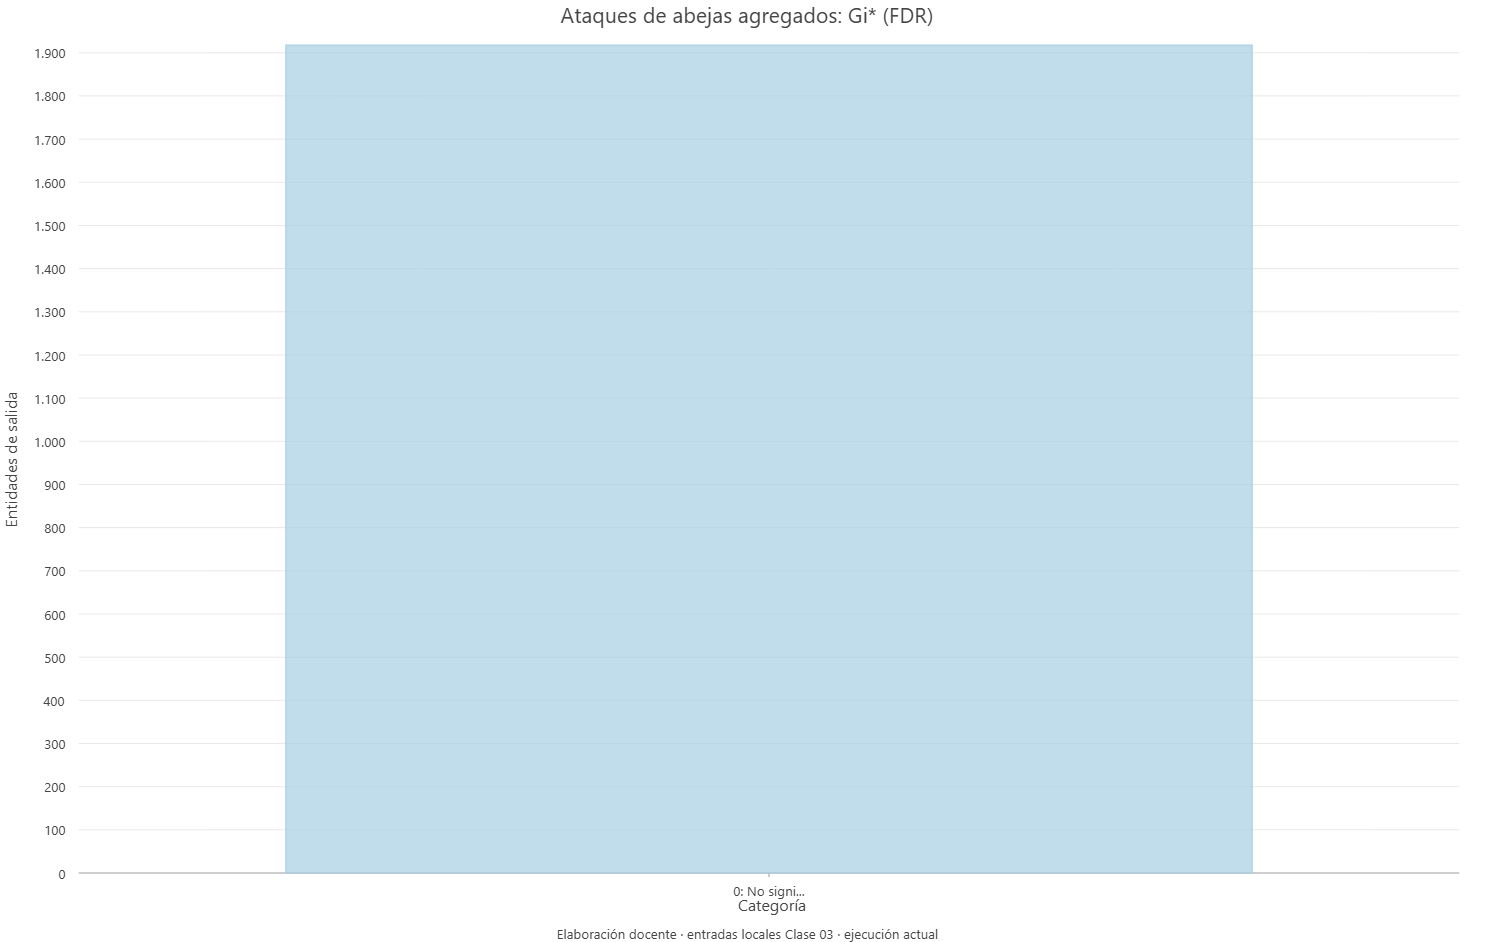

Ataques de abejas agregados: Gi* (FDR) {'0: No significativo': 1918}


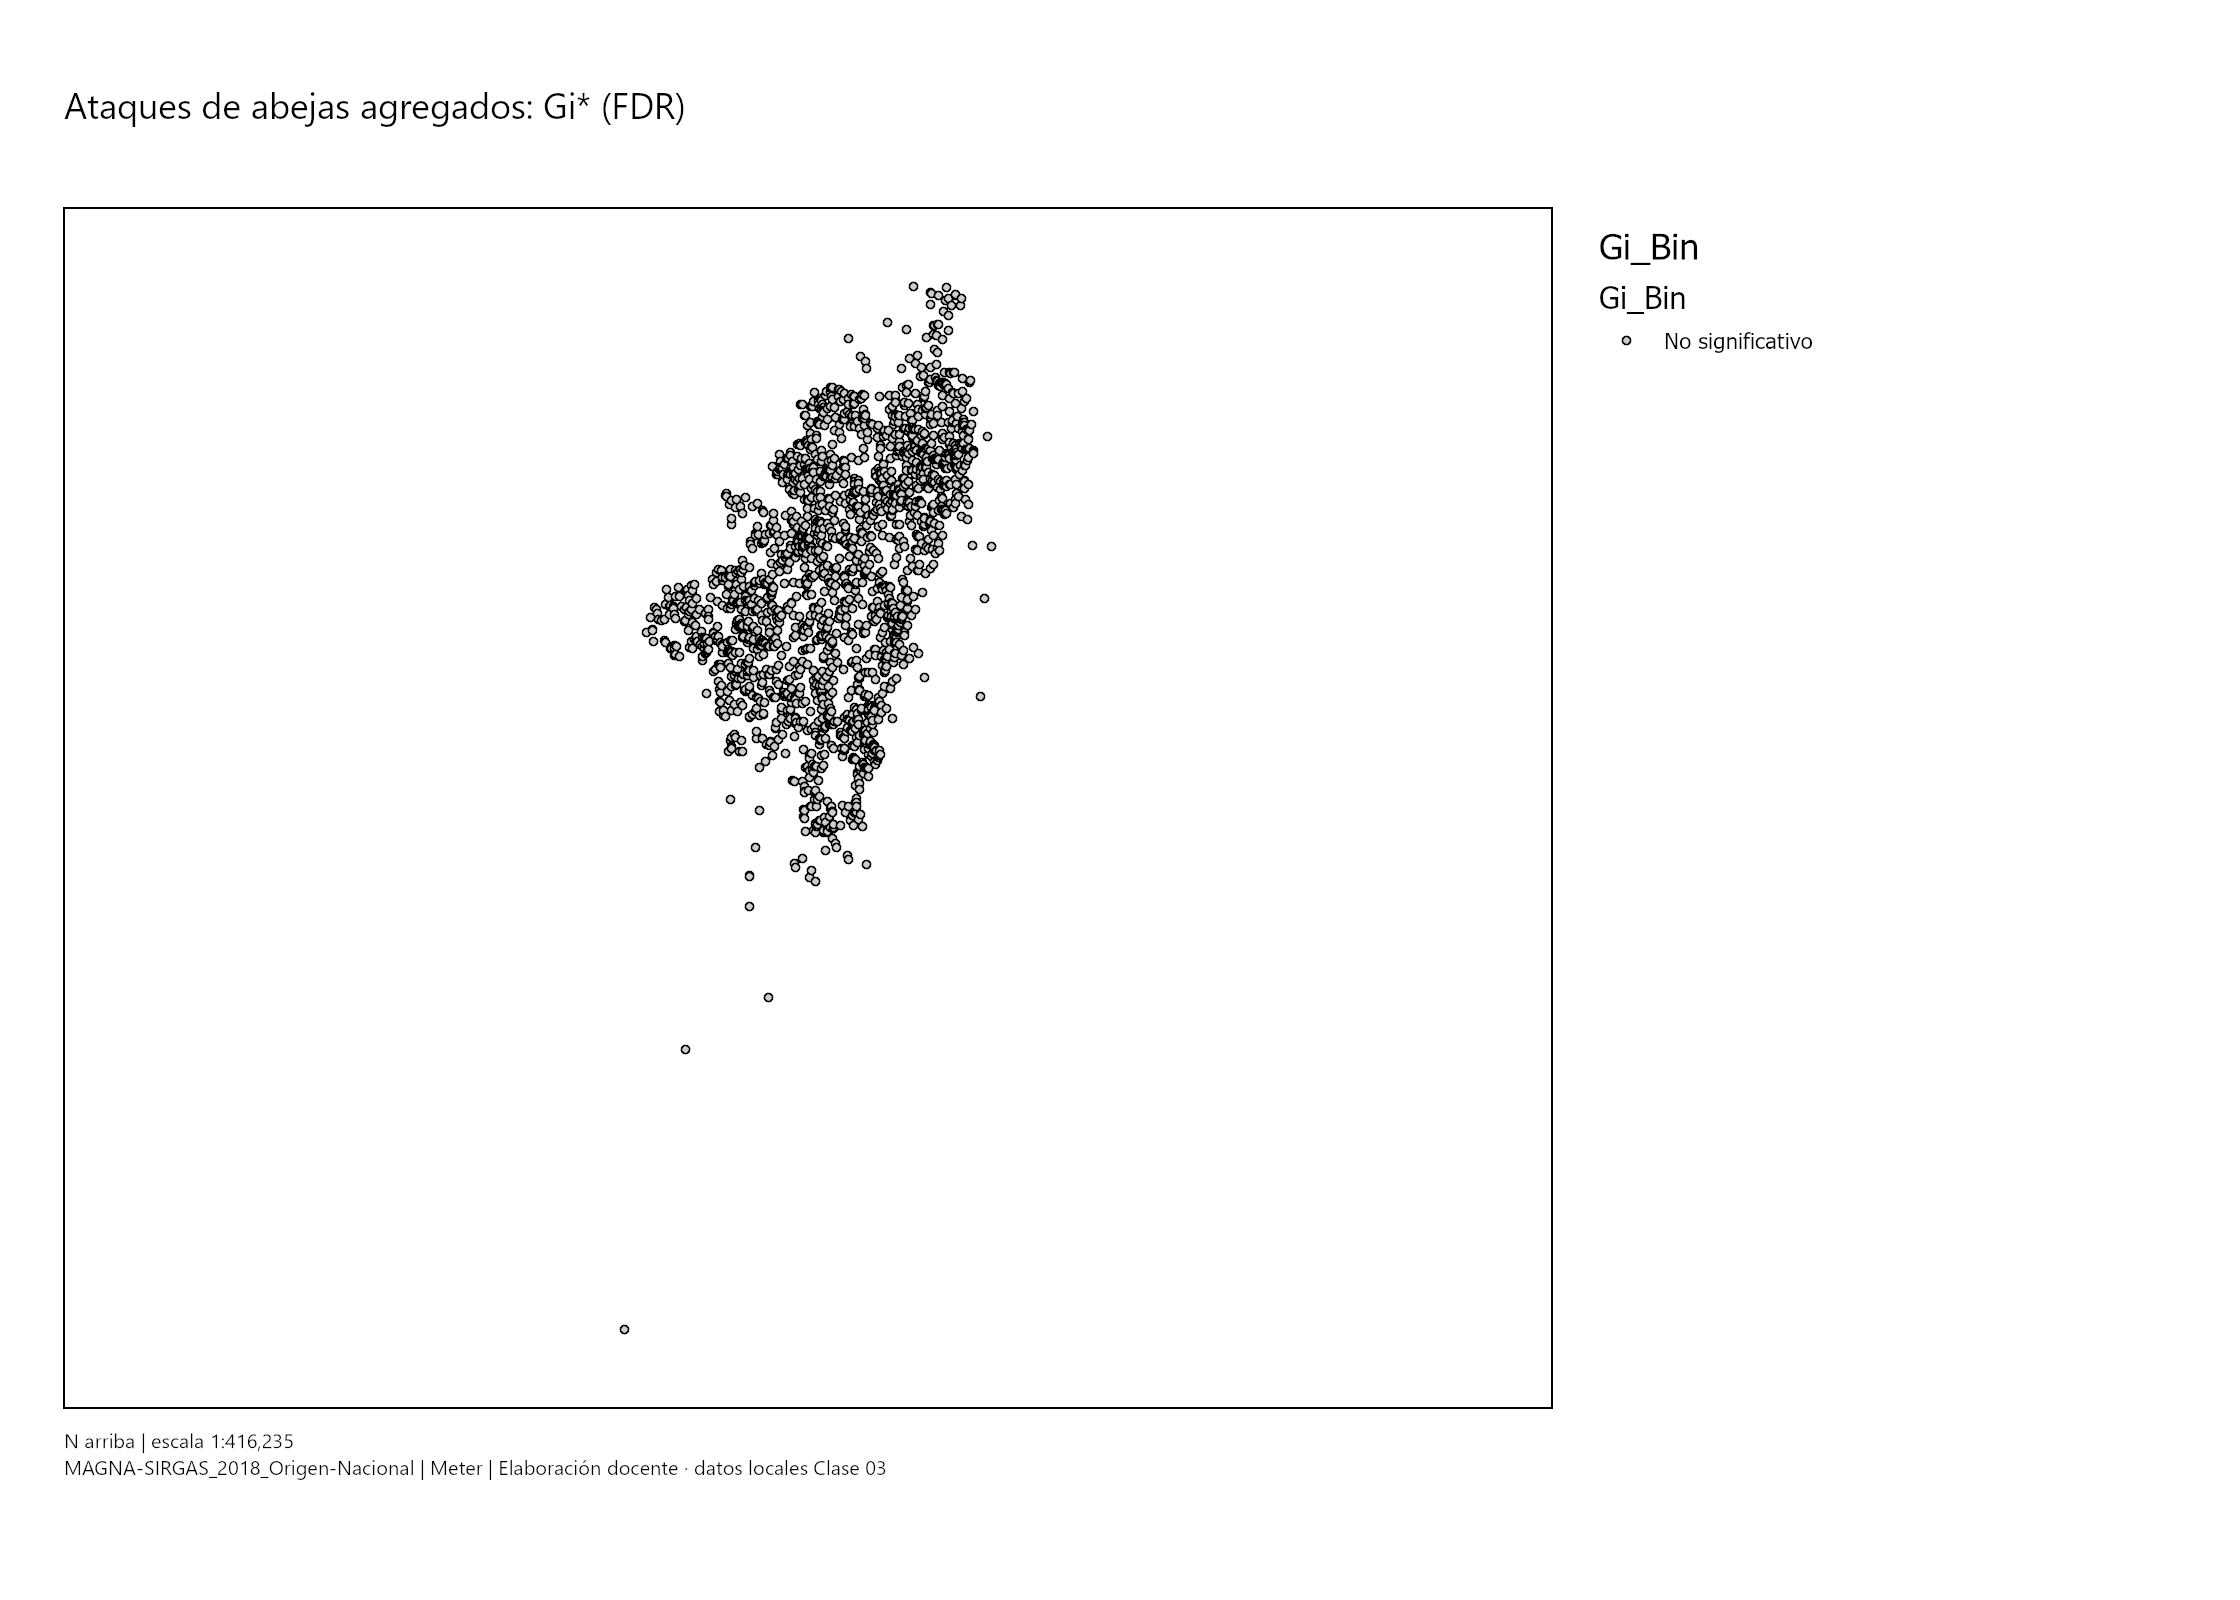

CRS: MAGNA-SIRGAS_2018_Origen-Nacional | unidades: Meter | entidades: 1918
Significativas: 0 | no significativas: 1918 | sin resultado: 0
Barras = entidades por clase; no suman ICOUNT ni miden riesgo individual.
Proyecto local: clase03_resultados.aprx | PNG nuevos del auxiliar: ['eda_siniestros_mes.png', 'eda_siniestros_localidad.png', 'mapa_siniestros_upz.png', 'mapa_siniestros_2020_upz.png', 'mapa_cubo_ubicaciones.png', 'mapa_cubo_tendencias.png', 'arcgis_mapa_emerging_hotspot_patrones_leyenda.png', 'arcgis_mapa_optimized_hotspot_2020plus_leyenda.png', 'escena_cubo_count_3d.png', 'arcpy_chart_optimized_hotspot_colegios.png', 'arcgis_mapa_optimized_hotspot_colegios_leyenda.png', 'arcpy_chart_optimized_hotspot_abejas.png', 'arcgis_mapa_optimized_hotspot_abejas_leyenda.png']
Bloqueos visuales: Ninguno detectado por código; revisar imágenes y escena.


In [21]:
# Reutiliza el mismo criterio de lectura; no presupone el cero significativo histórico.
weighted_oha_visuals(abejas_collect, optimized_hotspot_abejas, 'abejas', 'Ataques de abejas agregados')
project.save()
print('Proyecto local:', aprx_path.name, '| PNG nuevos del auxiliar:', visual_outputs)
print('Bloqueos visuales:', visual_blocks or 'Ninguno detectado por código; revisar imágenes y escena.')

**Lectura de abejas actuales:** 1.918 ubicaciones representan ICOUNT=2.173, sin pesos nulos ni cero. Todas quedaron Gi_Bin=0 con distancia automática 2.201,9014 m: sin significancia local tras FDR en esta configuración. El 1,3 % tuvo menos de ocho vecinos; no significancia no demuestra ausencia de incidentes.

## 15. Lectura integrada

### Resultados históricos de la práctica fuente — no ejecución de Clase 03

| Salida | Resultado | Lectura |
|---|---:|---|
| Pasos temporales del cubo | 14 | Semestres entre 2015 y 2021. |
| Bins totales | 132.468 | Agregación espacio-tiempo completa. |
| Tendencia global `COUNT` | z=0,3285; p=0,7426 | No significativa globalmente. |
| Persistent Hot Spot | 175 | Zonas con concentración alta sostenida. |
| Intensifying Hot Spot | 49 | Zonas donde el patrón se fortalece. |
| Oscillating Hot Spot | 363 | Zonas con alternancia temporal. |
| Persistent Cold Spot | 538 | Zonas frías sostenidas. |
| Optimized Hot Spot 2020+ | 871 polígonos | Contraste 2D acumulado reciente. |
| Entidades significativas OHSA 2020+ | 553 | Resultado con corrección FDR. |

### Interpretación

- El cubo no debe verse solo como producto visual: es una estructura de agregación y prueba.
- La tendencia global no significativa no impide que existan patrones locales relevantes.
- Para priorizar, los hot spots persistentes e intensificados son más accionables que una concentración acumulada sin historia temporal.
- Los cold spots requieren cuidado: pueden ser zonas de menor exposición, control efectivo o subregistro.
- La escala espacial y temporal debe documentarse siempre.

## 16. Referencias oficiales

- Esri ArcGIS Pro — [Create Space Time Cube By Aggregating Points](https://doc.esri.com/en/arcgis-pro/latest/tool-reference/space-time-pattern-mining/create-space-time-cube.htm)
- Esri ArcGIS Pro — [Visualizing cube data](https://doc.esri.com/en/arcgis-pro/latest/tool-reference/space-time-pattern-mining/visualizing-cube-data.htm)
- Esri ArcGIS Pro — [Visualize Space Time Cube in 3D](https://pro.arcgis.com/en/pro-app/latest/tool-reference/space-time-pattern-mining/visualizecube3d.htm)
- Esri ArcGIS Pro — [Emerging Hot Spot Analysis](https://doc.esri.com/en/arcgis-pro/latest/tool-reference/space-time-pattern-mining/emerginghotspots.htm)
- Esri ArcGIS Pro — [Learn more about Emerging Hot Spot Analysis](https://doc.esri.com/en/arcgis-pro/latest/tool-reference/space-time-pattern-mining/learnmoreemerging.htm)
- Esri ArcGIS Pro — [Optimized Hot Spot Analysis](https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-statistics/optimized-hot-spot-analysis.htm)
- Esri ArcGIS Pro — [Hot Spot Analysis Getis-Ord Gi*](https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-statistics/hot-spot-analysis.htm)
- Esri ArcGIS Pro — [ArcPy Charts module](https://pro.arcgis.com/en/pro-app/latest/arcpy/charts/what-is-the-charts-module.htm)

## Procedencia y estado de la adaptación local

Entradas de solo lectura: `99 - Recursos/datos/clase_03/entradas.gdb` (SiniestrosViales, UPZ, Colegios_Colombia_CollectEvents e Incidentes_Control_Abejas_CollectEvents) y el NetCDF contiguo. Véase [procedencia y comprobación de las copias](../datos/clase_03/README.md). Los preparados conservan el Integrate/CollectEvents histórico; aquí no se repiten ni se reparan, imputan o deduplican datos.

Cada preparación crea `99 - Recursos/salidas_clase_03/practica_01/run_<identificador>/`, con `trabajo.gdb`, `scratch.gdb`, reportes, CSV y gráficos. El NetCDF histórico se copia allí antes de usarlo: Emerging modifica exclusivamente esa copia, que ya contiene análisis históricos. La creación opcional permanece comentada y apunta a la copia, nunca a DATA_DIR.

**Ejecución actual, 17/09/2026.** Jupyter real, kernelspec `python3` verificado contra Python Pro 3.13.7, ArcGIS Pro 3.6.2, licencia ArcInfo; `PYTHONNOUSERSITE=1`. nbclient ejecutó 21 celdas en orden (timeout 1.800 s/celda), guardando cada celda con contadores/MIME auténticos. Creación opcional del cubo no ejecutada. Ocho mapas 2D, una escena 3D, siete gráficos ArcGIS: 16 PNG incrustados, nueve CSV y cero outputs de error. Se revisaron imágenes, TREND_BIN, colores categóricos y cámara local; etiquetas abreviadas y oclusión requieren tablas/leyendas. Interacción nativa de Obsidian/ArcGIS Pro no comprobada.

**Cierre pendiente:** último intento 186,952 s incluyendo controles y cierre. Después de la última celda y de verificar entradas, `shutdown_request` terminó con **4294967295**, controlador 1 y error fatal `_Py_GetConfig`/GIL en finalización. No se certifica ejecución integral limpia. Dos intentos anteriores conservados cerraron con **3221227010**: primero detectó marco 3D en modo MAP; segundo exportó Emerging/escena vacíos. Se corrigieron solo vista CIM SceneLocal, cámara con Z finita y niveles de símbolo heredados incompatibles con el renderer nuevo. El último intento corrigió los renderizados, no el entorno ni la causa del cierre.

Antes/después coincidieron filas, OID, atributos, WKB, esquema y CRS de las cuatro entradas con sus originales; NetCDF idéntico mediante filecmp binario. Solo se guardan aquí resultados del último intento analítico completo, sin mezclar corridas ni declararlo exitoso de extremo a extremo. Respaldos e intentos anteriores permanecen intactos. Referencias web conservadas sin nueva consulta; correcciones respaldadas en API/CIM instalada. El video sigue PARCIAL; clase no declarada completa.

[Resultados actuales](../salidas_clase_03/practica_01/run_b01a1f3965b84ae2a861e185ead354dc/) · [APRX](../salidas_clase_03/practica_01/run_b01a1f3965b84ae2a861e185ead354dc/clase03_resultados.aprx) · [Registro](../salidas_clase_03/practica_01/jupyter_1c5ae5a89ed14ae78bab93ff1f7cb1c0/execution.json) · [stderr](../salidas_clase_03/practica_01/jupyter_1c5ae5a89ed14ae78bab93ff1f7cb1c0/kernel.stderr) · [Entradas antes/después](../salidas_clase_03/practica_01/jupyter_1c5ae5a89ed14ae78bab93ff1f7cb1c0/inputs_after.json) · [Seguimiento](../../odd/tasks/migracion-clase03.md).